In [58]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [59]:
features = pd.read_csv("src/data/training/processed/final_training_data.csv")

In [60]:
features['mix__sd_od_history_to_kyc_ratio'] = features['od__history_length_days'] / features['sd__age_since_first_kyc']

In [61]:
features = features.drop(columns=['user_id', 'default_date'])
features = features.loc[:, ~features.columns.str.startswith('dn__')]

In [62]:
reg_feats = ['reference_date',
'ob__limit_ref',
 'ob__max_to_avg_util_3m_ratio',
 'ob__open_limit_ref',
 'ob__avg_util_ref',
 'ob__max_util_3m',
 'ob__avg_util_3m',
 'madrid__avg_monthly_expenses_3m',
 'ob__od_enabled_zero_util_days_6m',
 'ob__partial_repayment_events_6m',
 'mix__sd_od_history_to_kyc_ratio',
 'sd__age_since_last_kyc',
 'ab__std_abs_change_6m',
 'sd__age',
 'ob__util_last2m_to_first2m_1y_ratio',
 'sd__max_daily_logins_12m',
 'ob__std_util_3m',
 'ab__bal_change_freq_3m',
 'ob__od_draw_days_6m',
 'sd__max_daily_logins_6m',
 'sd__age_since_first_kyc',
 'madrid__avg_monthly_salary_3m',
 'ab__max_one_day_drop_6m',
 'cb__worst_score',
 'mv__is_lisbon_v1',
 'ul__is_expat',
 'ab__inflow_spike_count_6m',
 'ob__util_range_3m',
 'ob__avg_util_change_last2m_to_first2m_1y',
 'madrid__avg_monthly_repayment_capacity_3m',
 'sd__membership_product']
clf_feats = ['reference_date',
'ob__open_limit_ref',
 'ob__avg_util_ref',
 'ob__limit_ref',
 'madrid__avg_monthly_salary_3m',
 'ul__is_expat',
 'ob__od_enabled_zero_util_days_6m',
 'madrid__avg_monthly_expenses_3m',
 'sd__age',
 'ob__max_to_avg_util_3m_ratio',
 'ob__max_util_change_3m',
 'sd__max_daily_logins_6m',
 'ab__avg_bal_3m',
 'cb__worst_score',
 'mix__sd_od_history_to_kyc_ratio',
 'ab__days_down_6m',
 'ab__inflow_spike_count_6m',
 'sd__max_daily_logins_12m',
 'ab__std_abs_change_6m',
 'ab__std_bal_change_3m',
 'ab__near_zero_days_6m',
 'ab__bal_change_freq_3m',
 'ep__cc_tbil_balance',
 'madrid__avg_monthly_repayment_capacity_3m',
 'ab__max_bal_change_3m',
 'ob__util_last2m_to_first2m_ratio',
 'ab__avg_bal_change_3m',
 'ob__avg_util_3m',
 'ab__max_one_day_drop_6m',
 'mv__is_lisbon_v1',
 'ob__partial_repayment_events_6m']

In [63]:
features_reg = features[reg_feats]
features_clf = features[clf_feats]

                                        feature  year  month        psi
0                                 ob__limit_ref  2017      1        NaN
1                                 ob__limit_ref  2017      2        NaN
2                                 ob__limit_ref  2017      3        NaN
3                                 ob__limit_ref  2017      4        NaN
4                                 ob__limit_ref  2017      5        NaN
5                                 ob__limit_ref  2017      6        NaN
6                                 ob__limit_ref  2017      7        NaN
7                                 ob__limit_ref  2017      8        NaN
8                                 ob__limit_ref  2017      9        NaN
9                                 ob__limit_ref  2017     10        NaN
10                                ob__limit_ref  2017     11   2.769720
11                                ob__limit_ref  2017     12   0.782029
12                                ob__limit_ref  2018      1   1

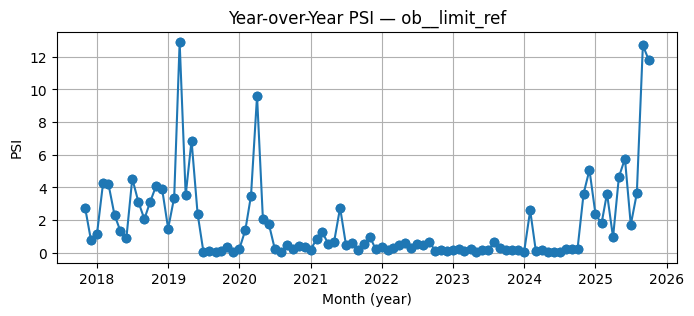

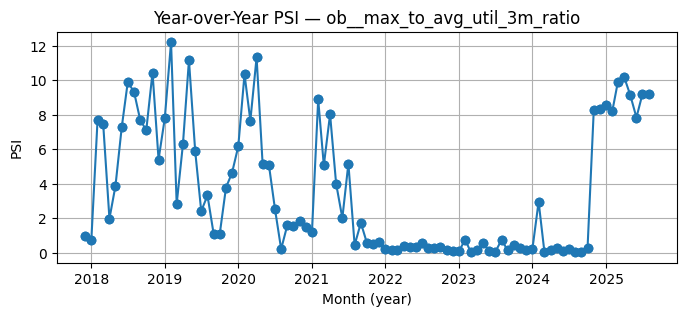

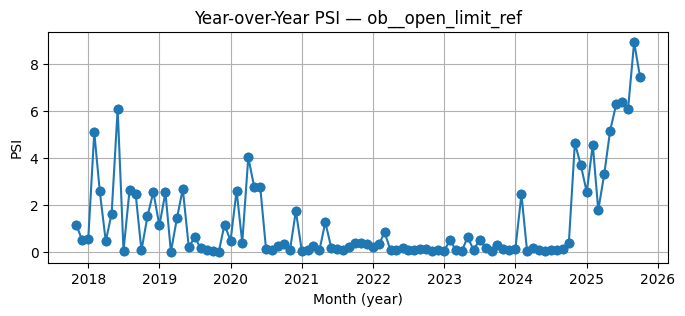

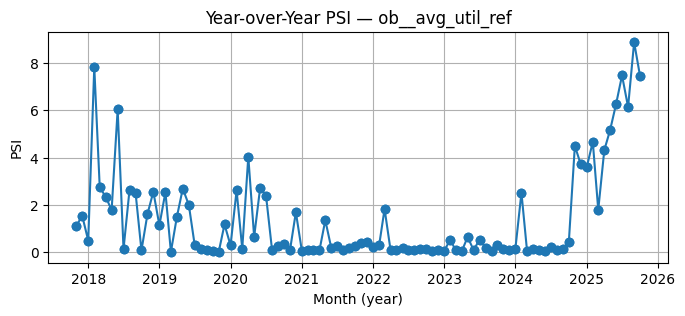

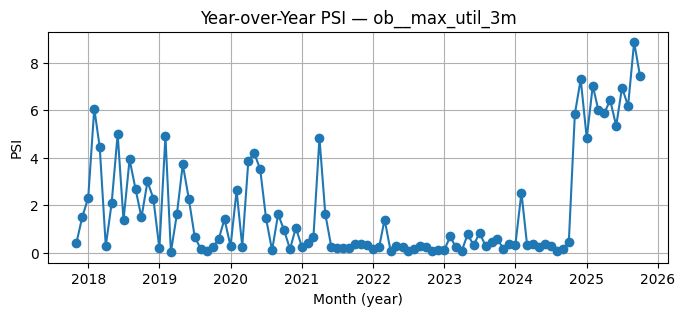

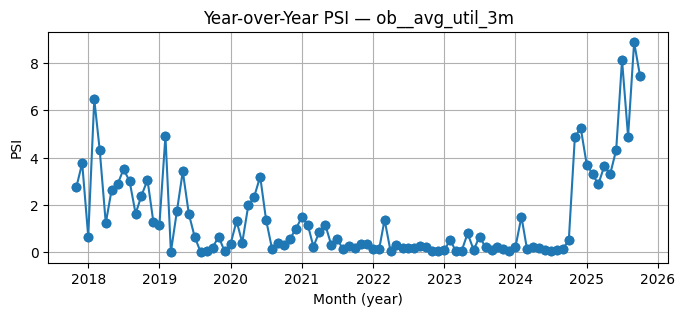

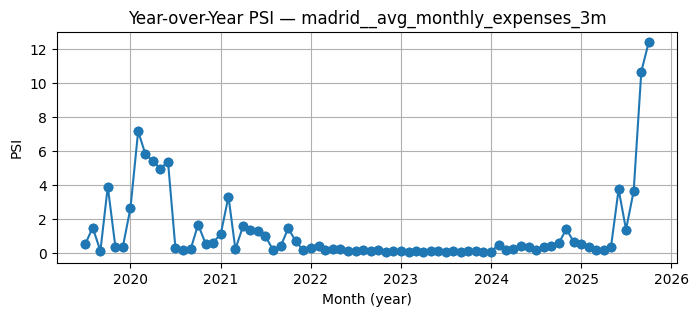

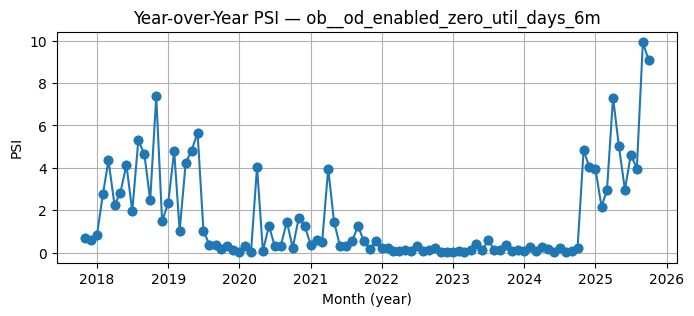

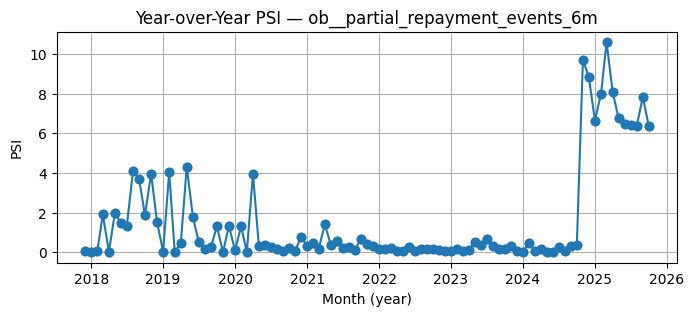

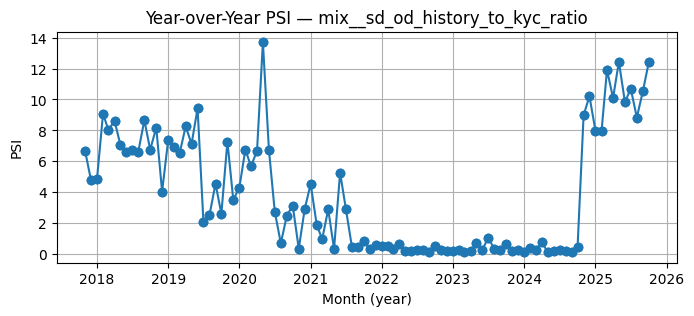

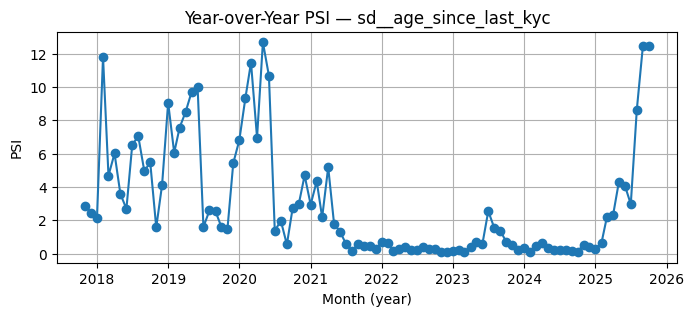

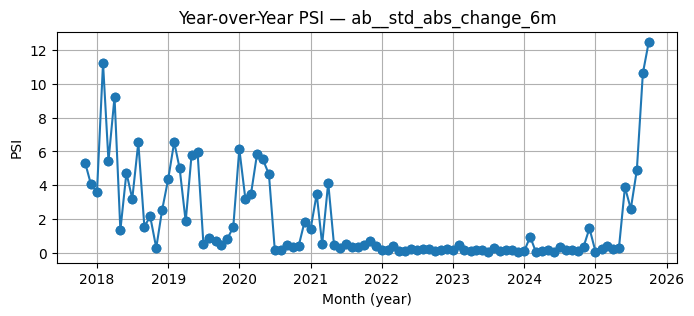

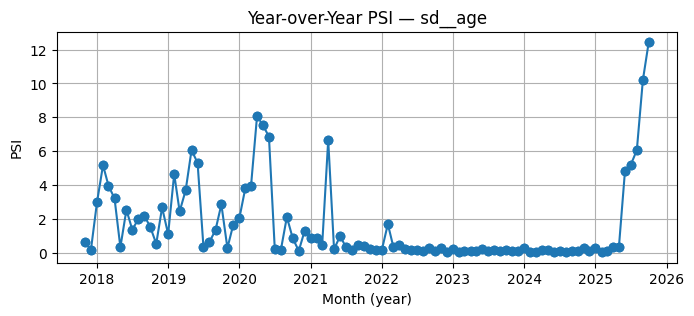

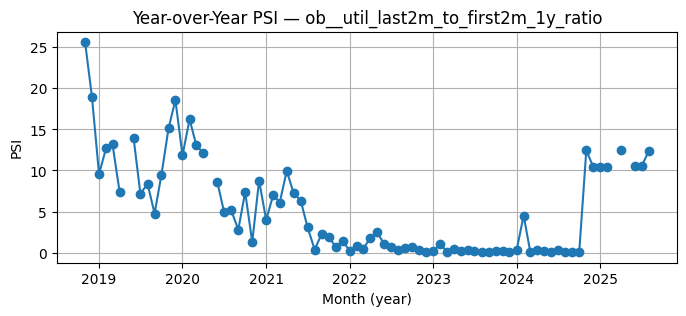

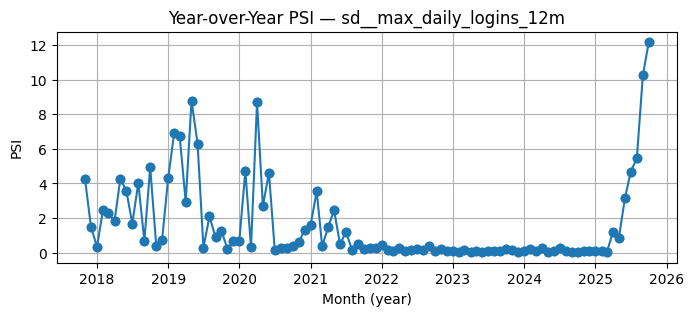

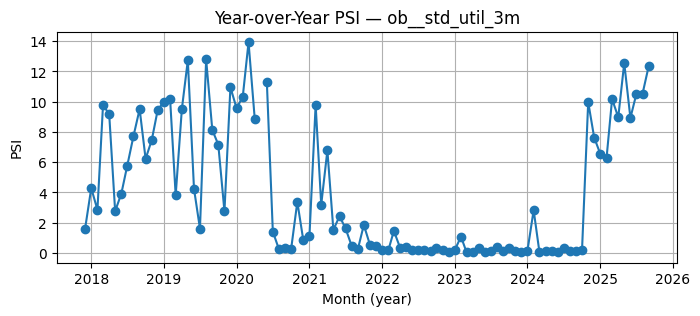

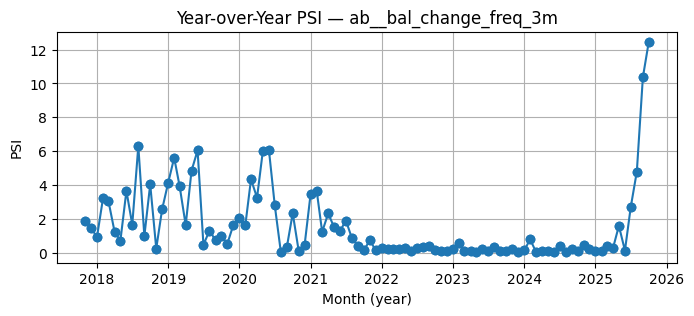

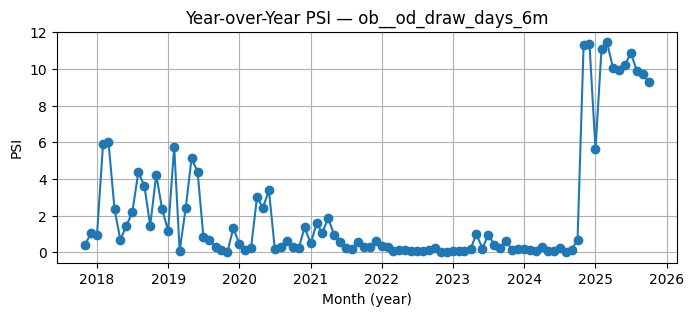

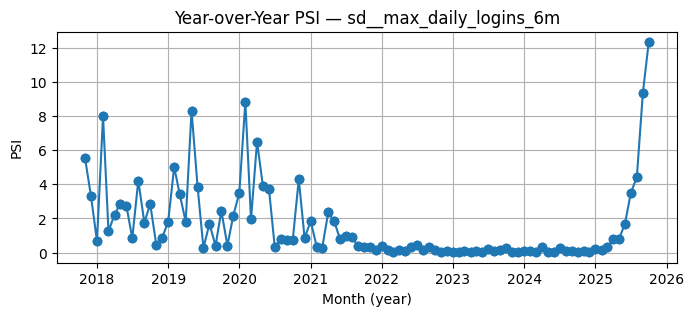

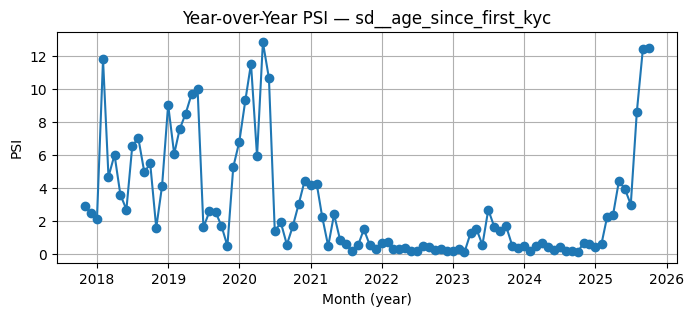

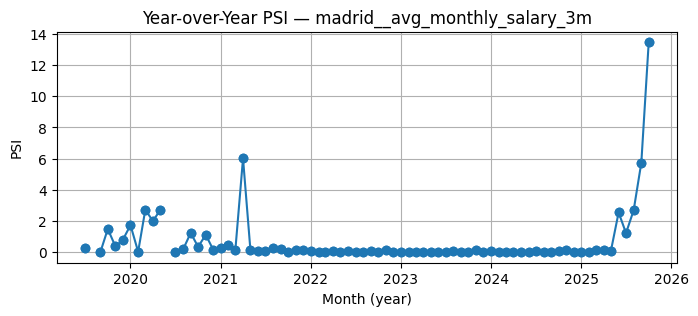

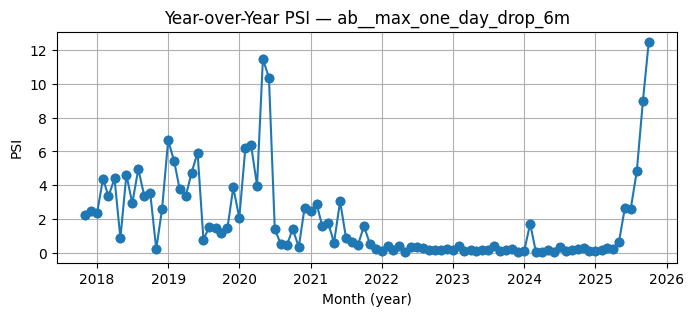

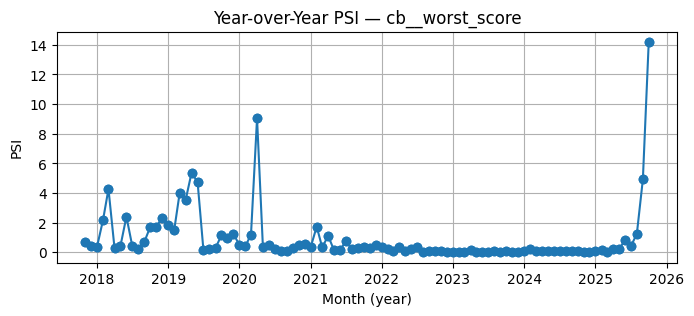

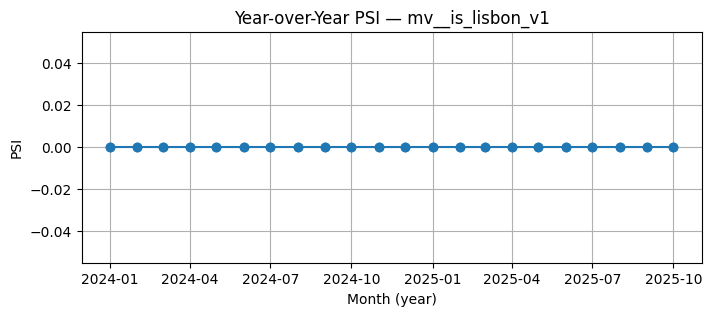

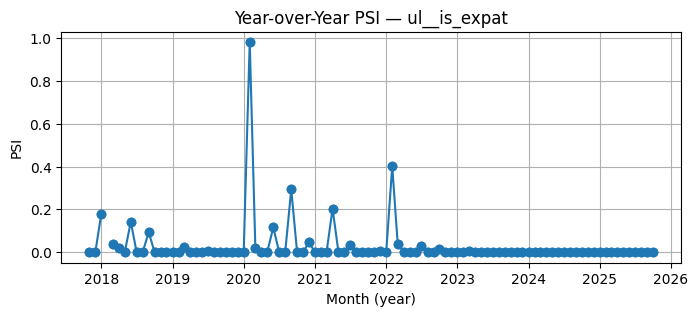

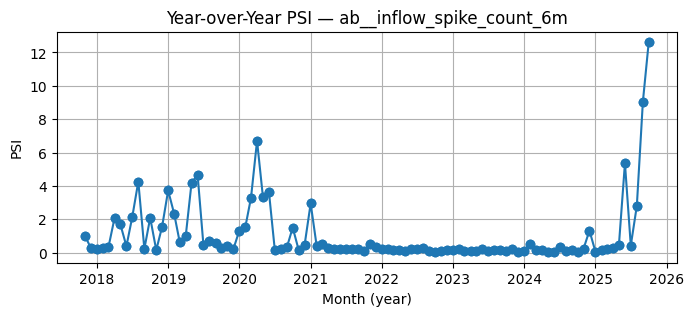

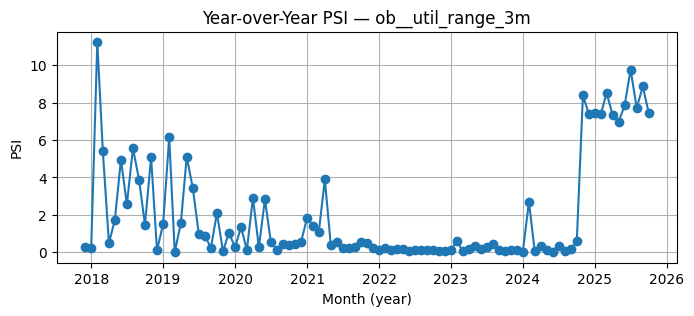

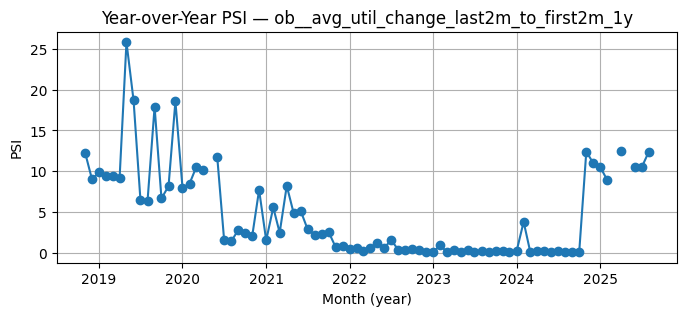

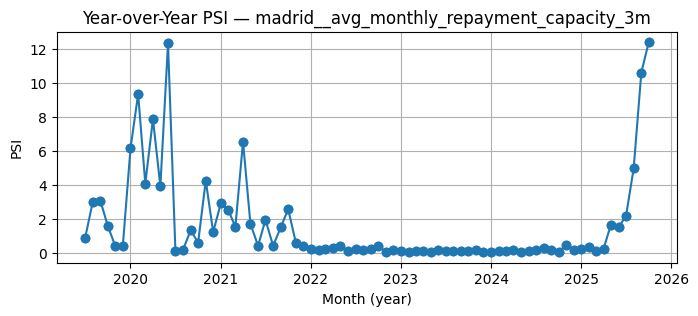

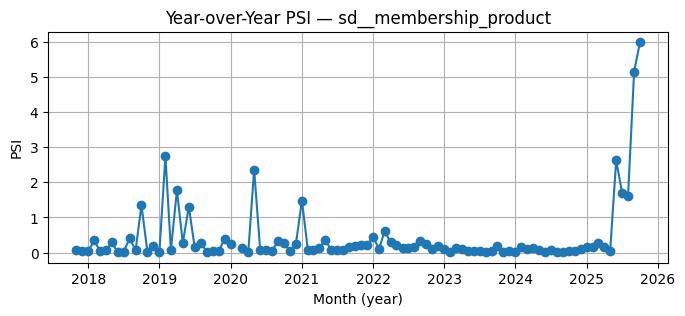

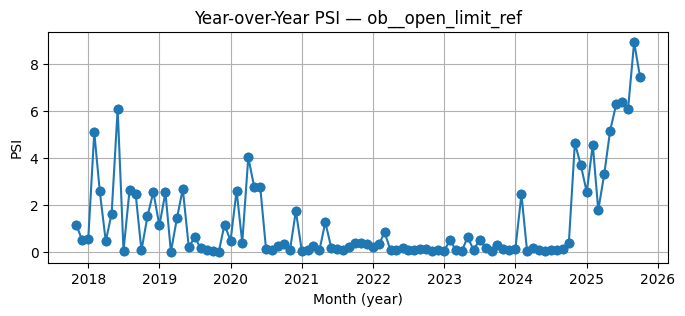

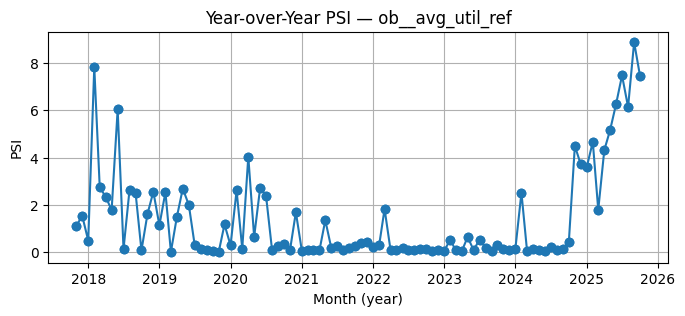

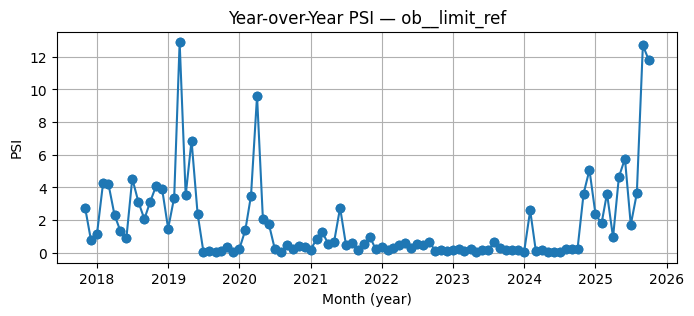

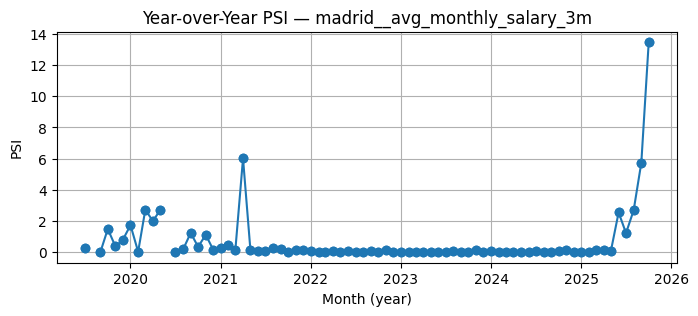

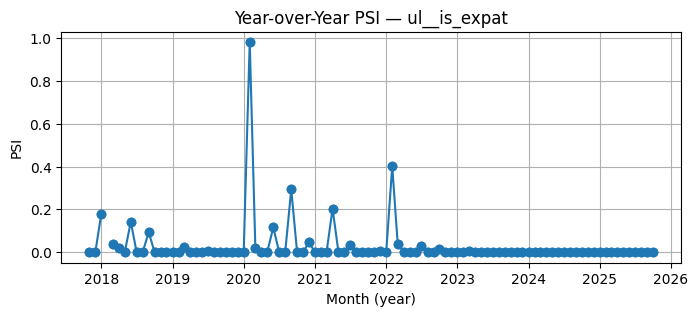

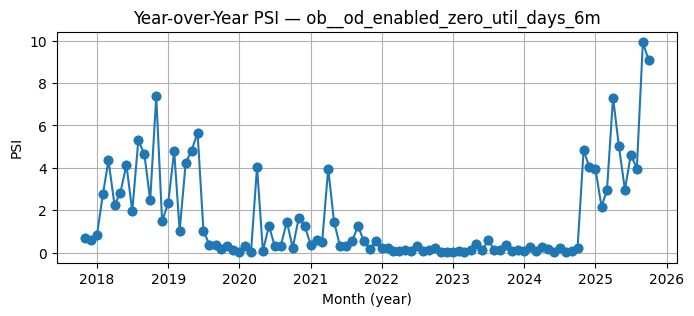

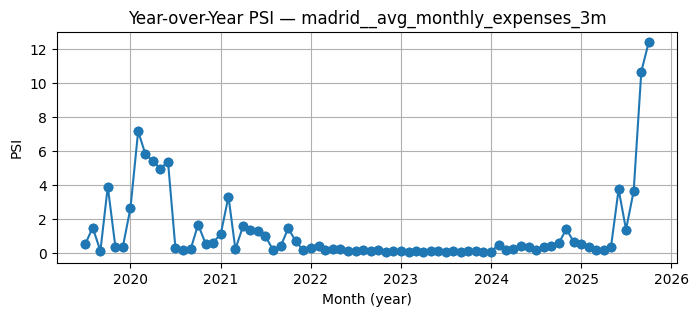

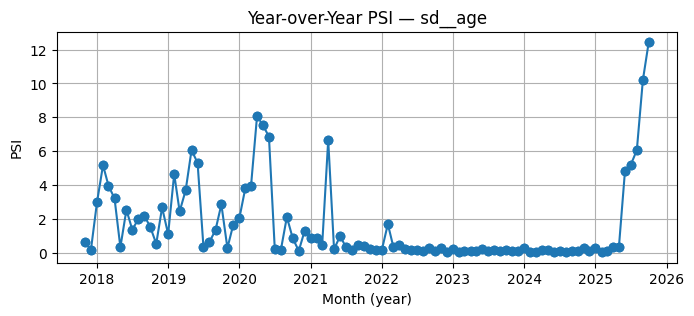

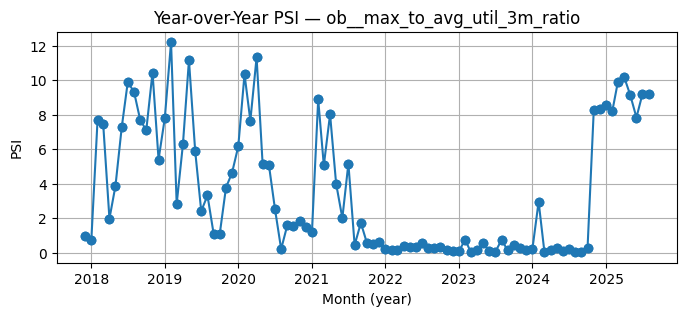

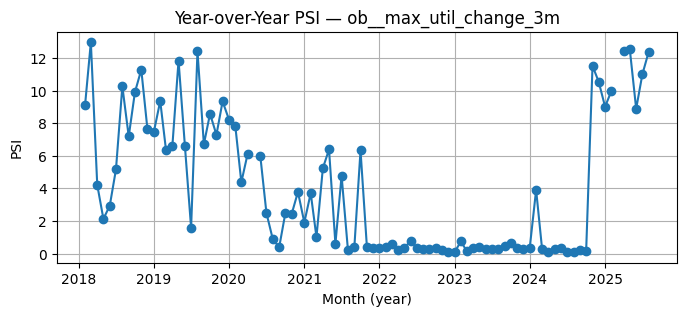

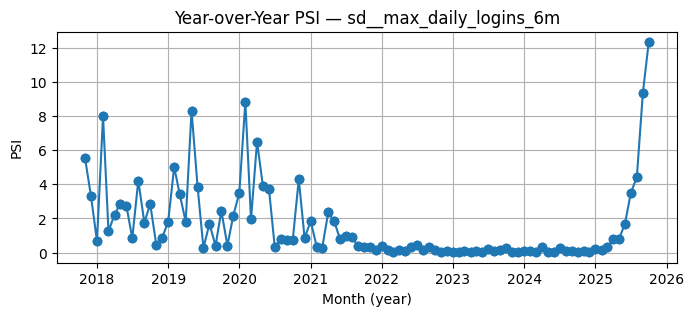

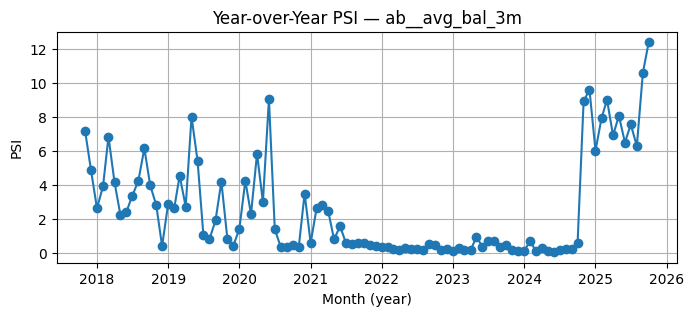

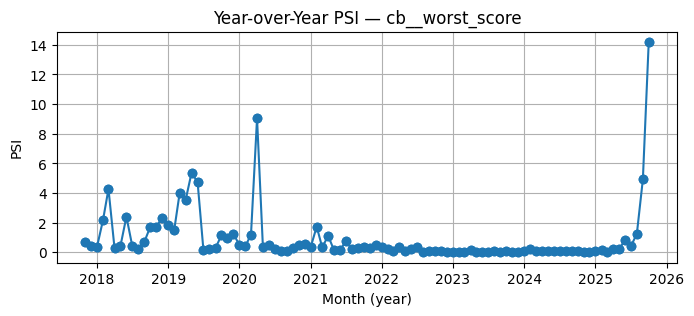

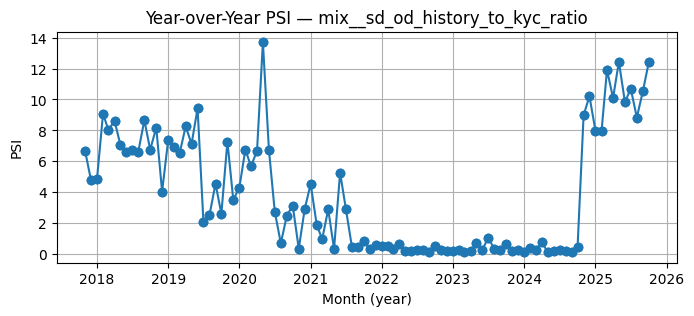

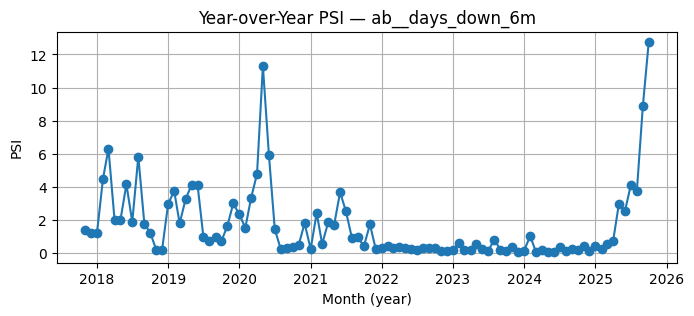

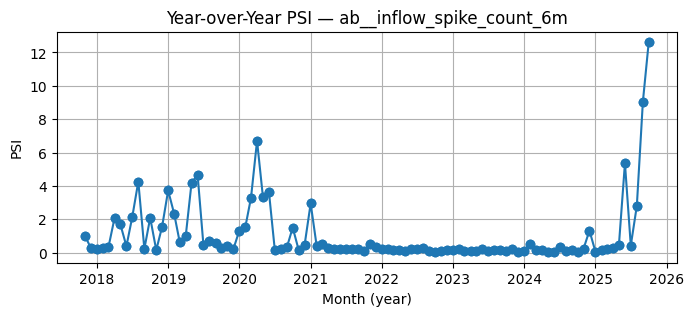

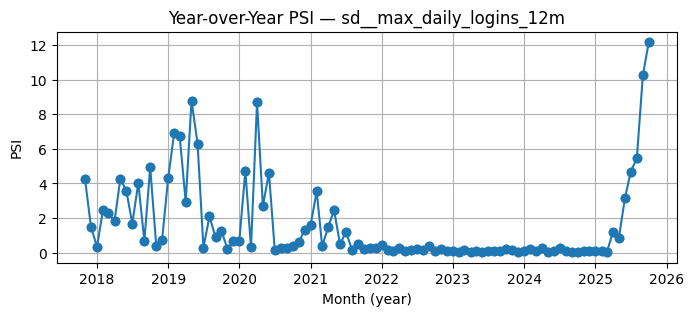

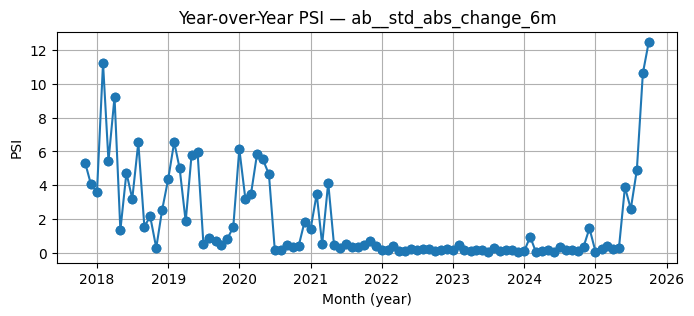

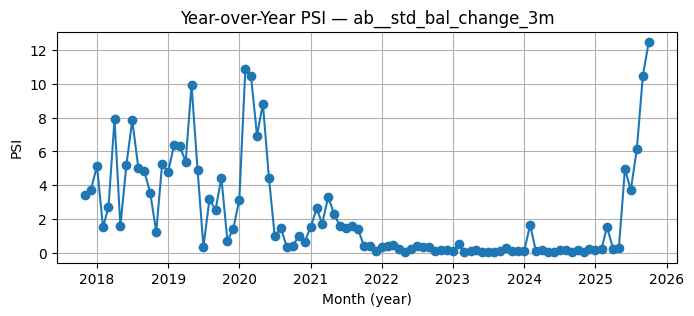

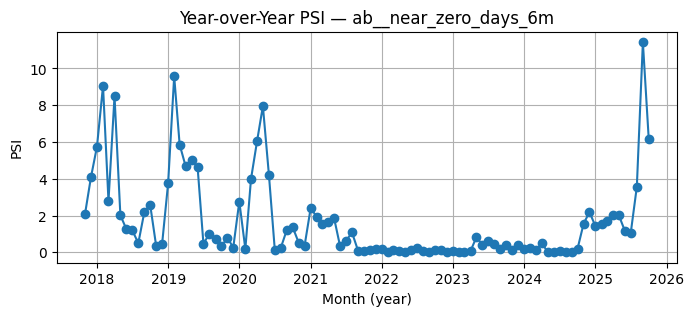

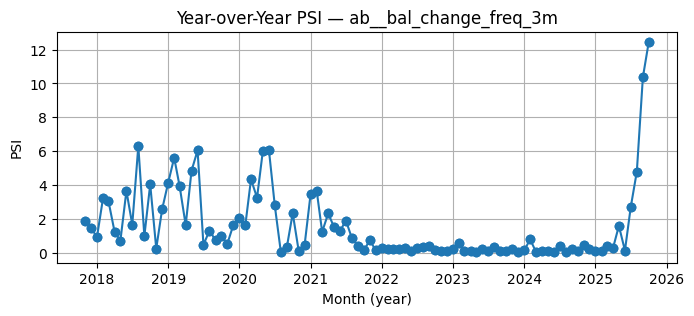

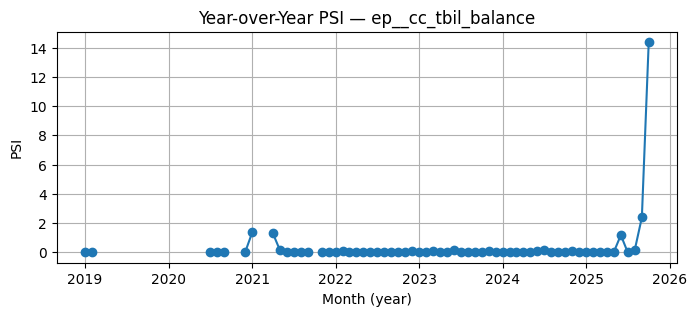

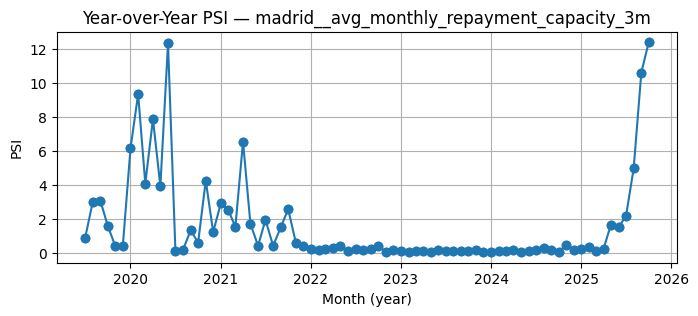

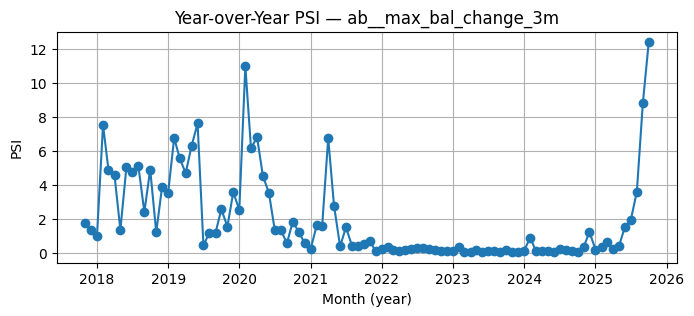

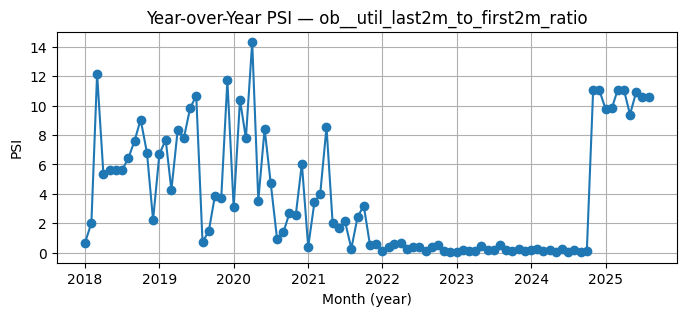

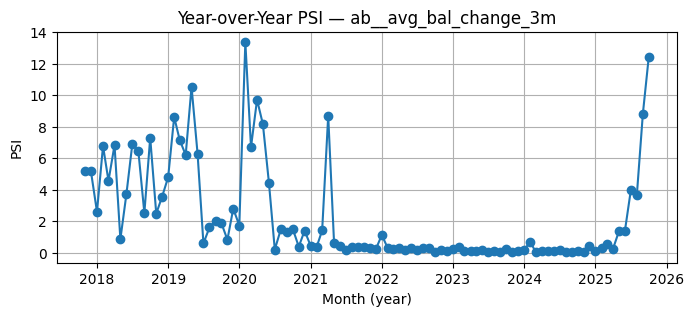

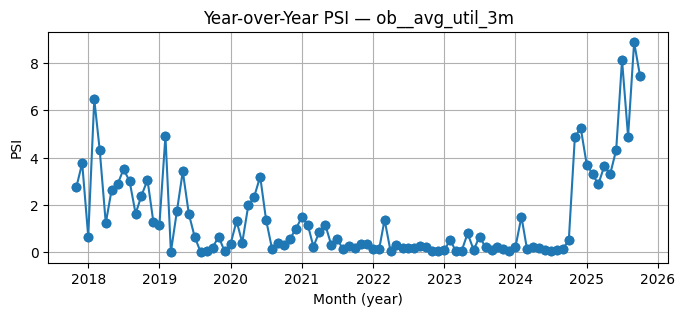

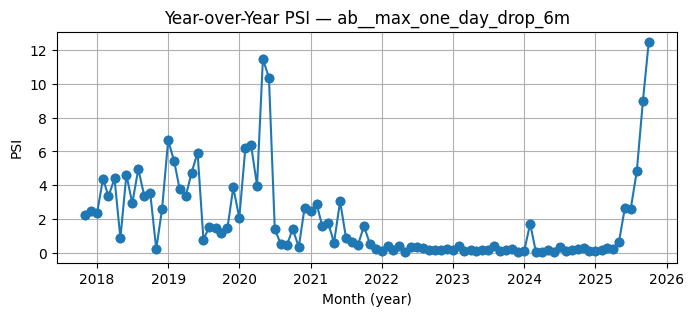

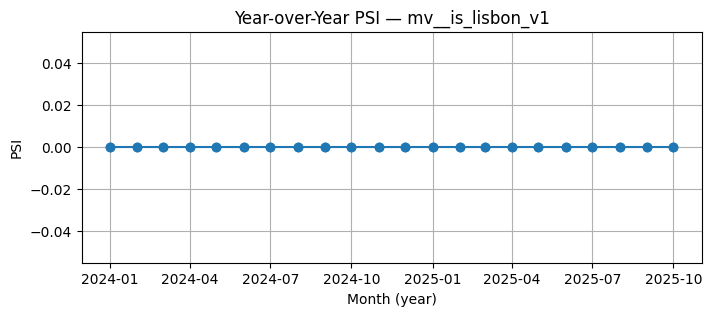

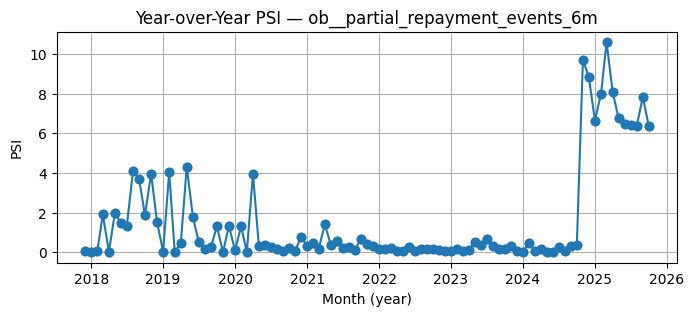

In [ ]:
def calculate_psi(expected, actual, buckets=10):
    expected = np.array(pd.Series(expected).dropna()).astype(float)
    actual = np.array(pd.Series(actual).dropna()).astype(float)
    if expected.size == 0 or actual.size == 0:
        return np.nan

    bins = np.unique(np.quantile(expected, np.linspace(0, 1, buckets + 1)))
    if bins.size < 2:
        return np.nan
    exp_perc = np.histogram(expected, bins=bins)[0] / expected.size
    act_perc = np.histogram(actual, bins=bins)[0] / actual.size
    exp_perc = np.where(exp_perc == 0, 1e-6, exp_perc)
    act_perc = np.where(act_perc == 0, 1e-6, act_perc)
    return np.sum((exp_perc - act_perc) * np.log(exp_perc / act_perc))

df = features.copy()
df['reference_date'] = pd.to_datetime(df['reference_date'])
df['year'] = df['reference_date'].dt.year
df['month'] = df['reference_date'].dt.month

features_reg_list = [f for f in features_reg.columns if f != "reference_date"]
features_clf_list = [f for f in features_clf.columns if f != "reference_date"]
feature_list = features_reg_list + features_clf_list

rows = []
years = sorted(df['year'].unique())

for feat in feature_list:
    for year in years:
        prev_year = year - 1
        if prev_year not in years:
            continue
        for month in sorted(df['month'].unique()):
            expected = df.loc[(df['year'] == prev_year) & (df['month'] == month), feat]
            actual = df.loc[(df['year'] == year) & (df['month'] == month), feat]
            psi_val = calculate_psi(expected, actual, buckets=10)
            rows.append({"feature": feat, "year": year, "month": month, "psi": psi_val})

psi_df = pd.DataFrame(rows)
psi_pivot = psi_df.pivot_table(index=['year', 'month'], columns='feature', values='psi')

print(psi_df)

for feat in feature_list:
    sub = psi_df[psi_df['feature'] == feat].sort_values(['year', 'month'])
    if sub['psi'].notna().sum() == 0:
        continue
    x = pd.to_datetime(sub['year'].astype(str) + '-' + sub['month'].astype(str) + '-01')
    plt.figure(figsize=(8, 3))
    plt.plot(x, sub['psi'], marker='o')
    plt.title(f'Year-over-Year PSI — {feat}')
    plt.xlabel('Month (year)')
    plt.ylabel('PSI')
    plt.grid(True)
    plt.show()

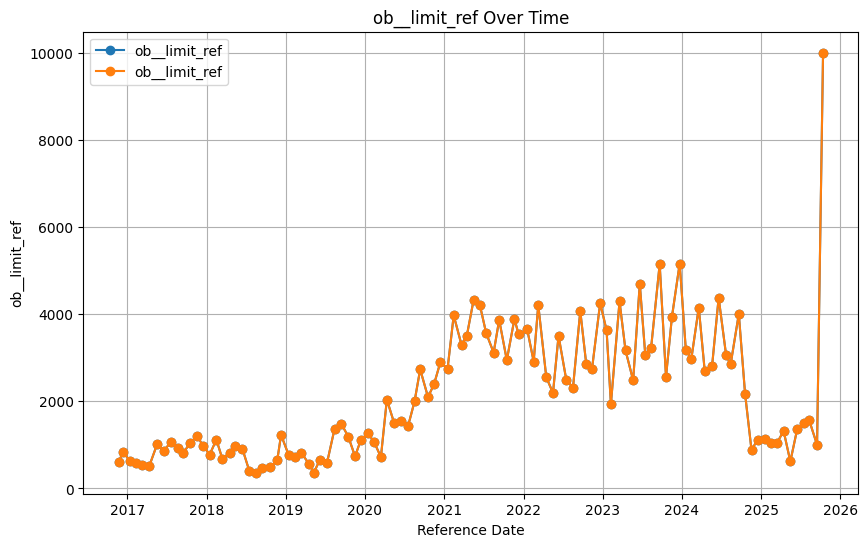

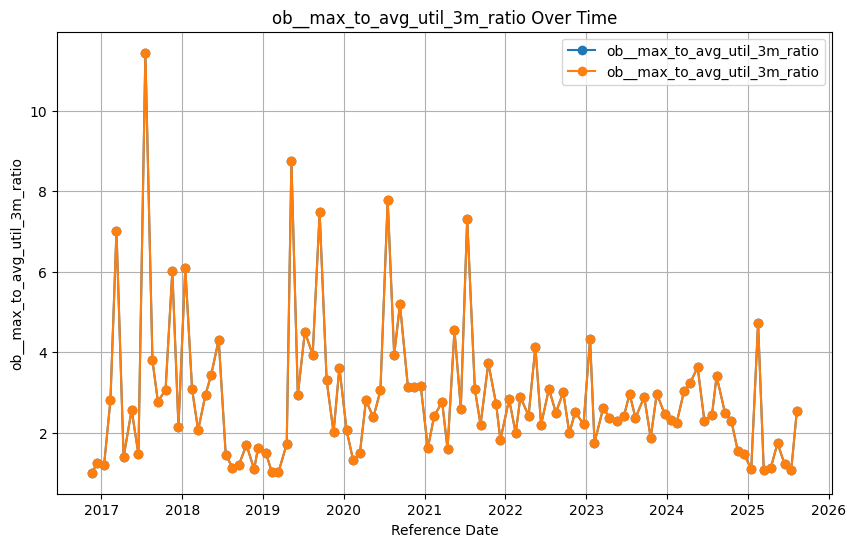

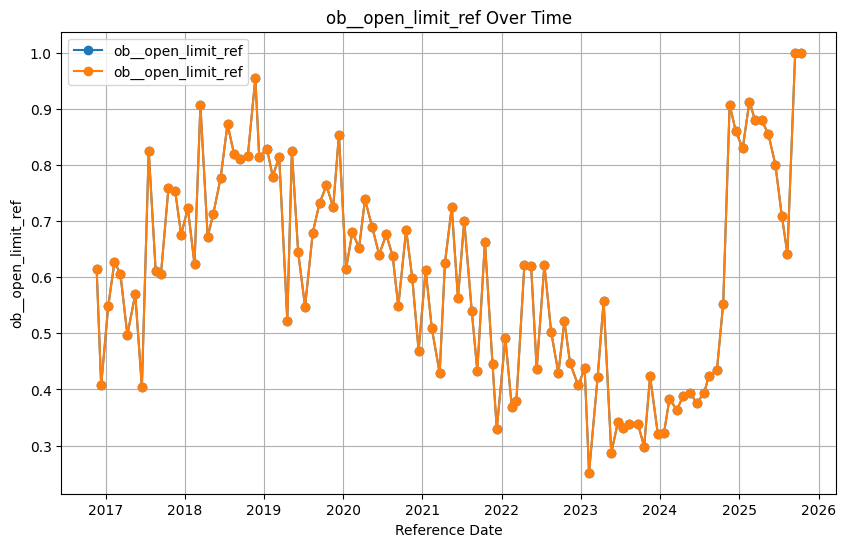

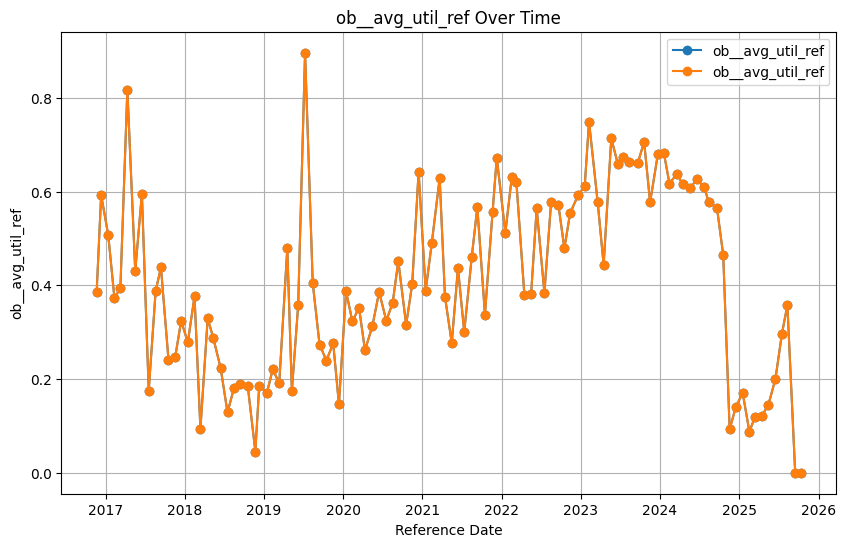

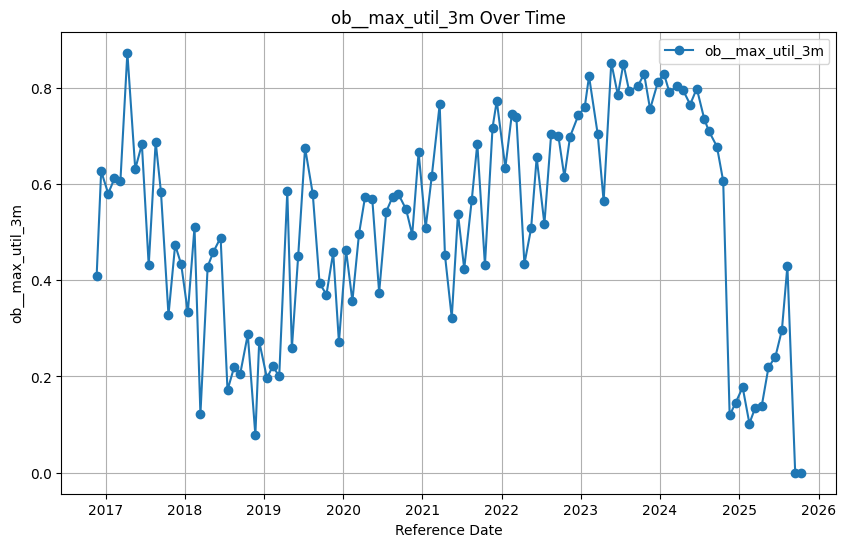

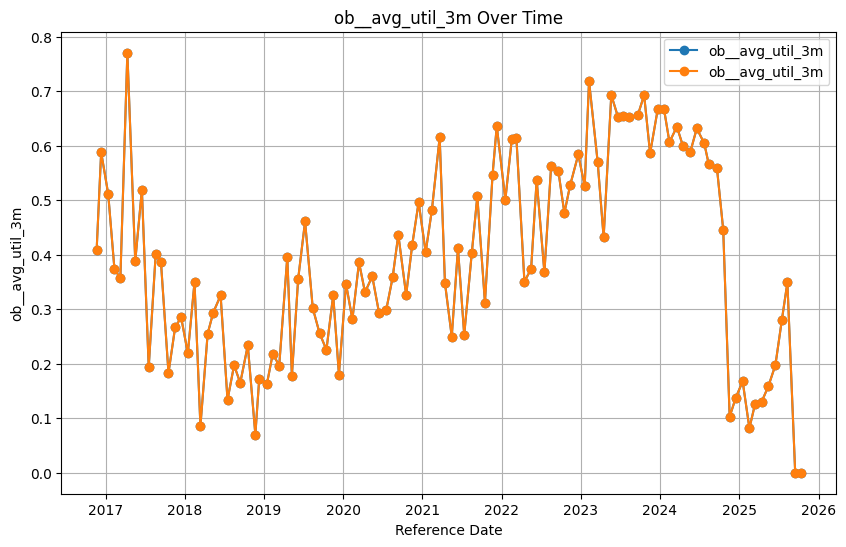

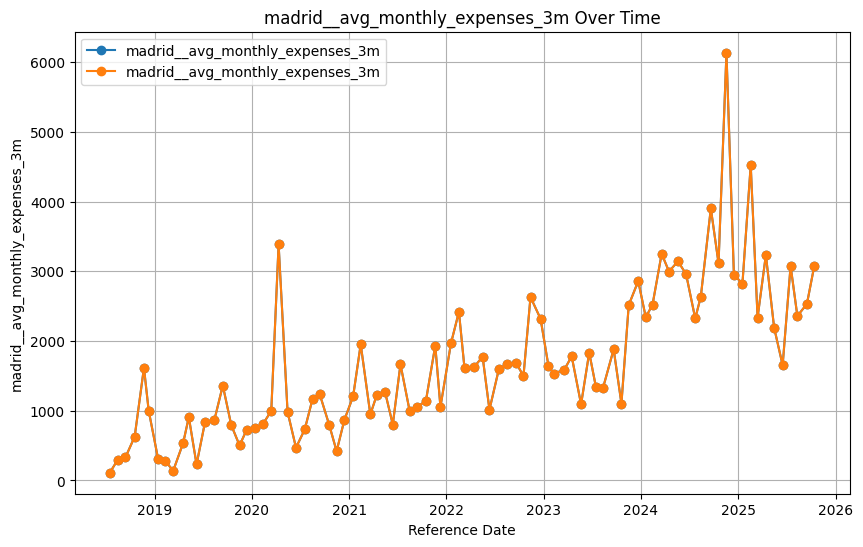

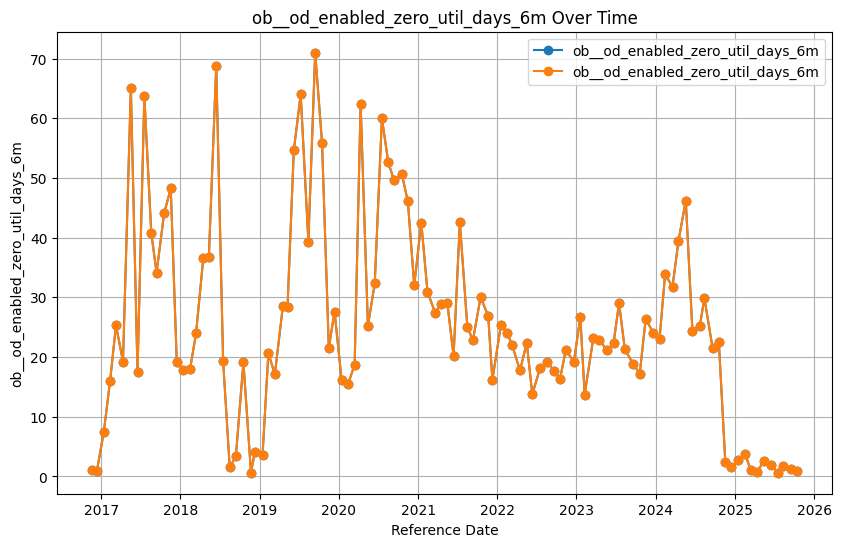

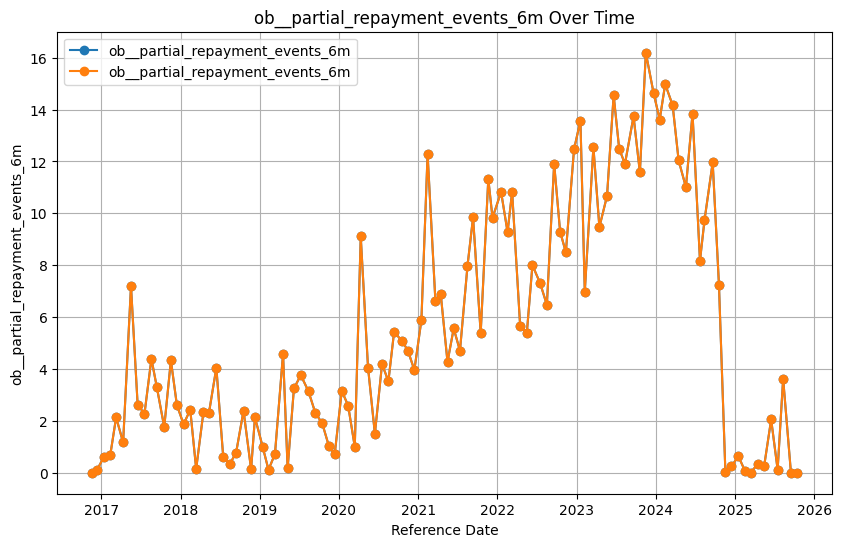

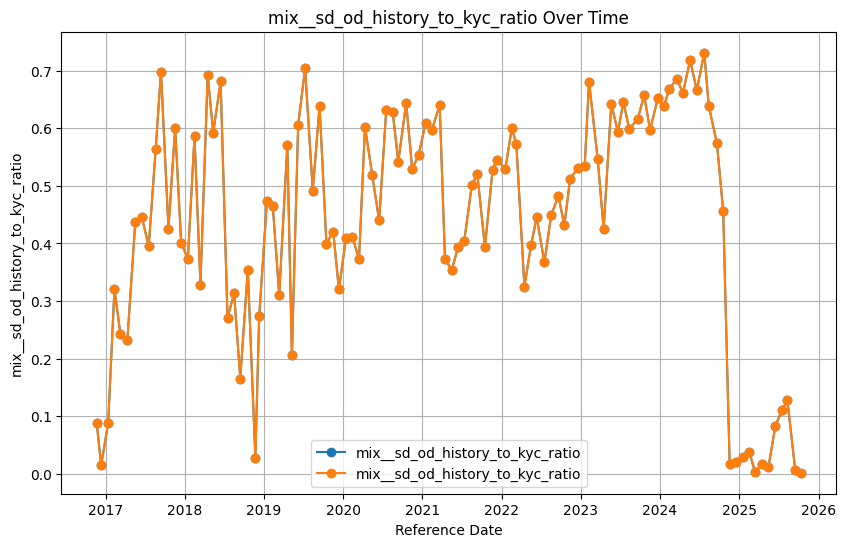

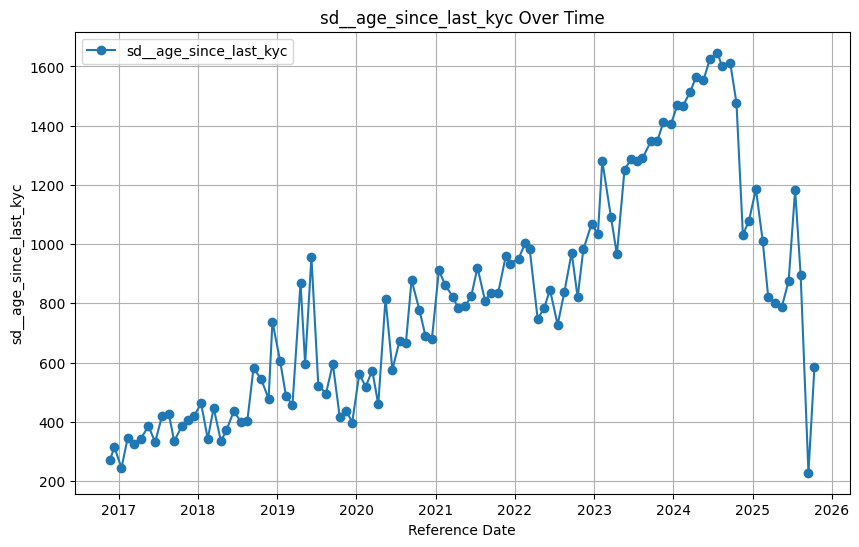

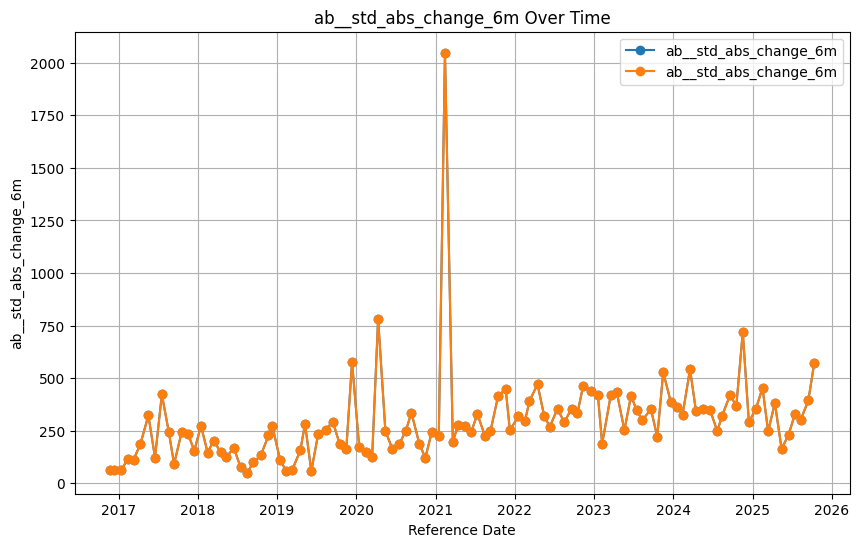

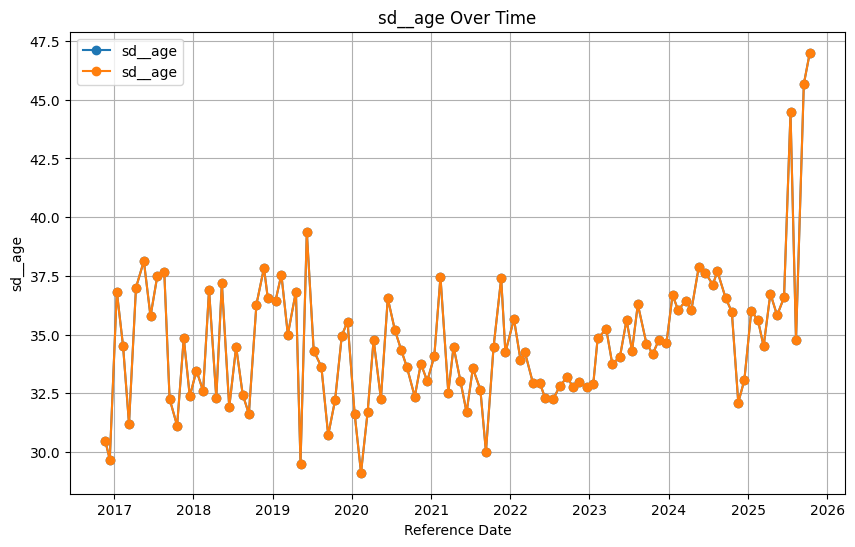

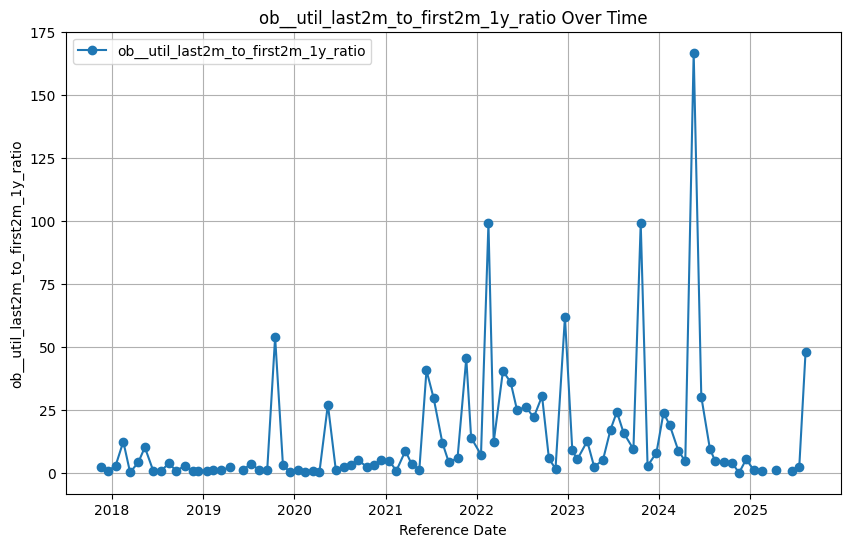

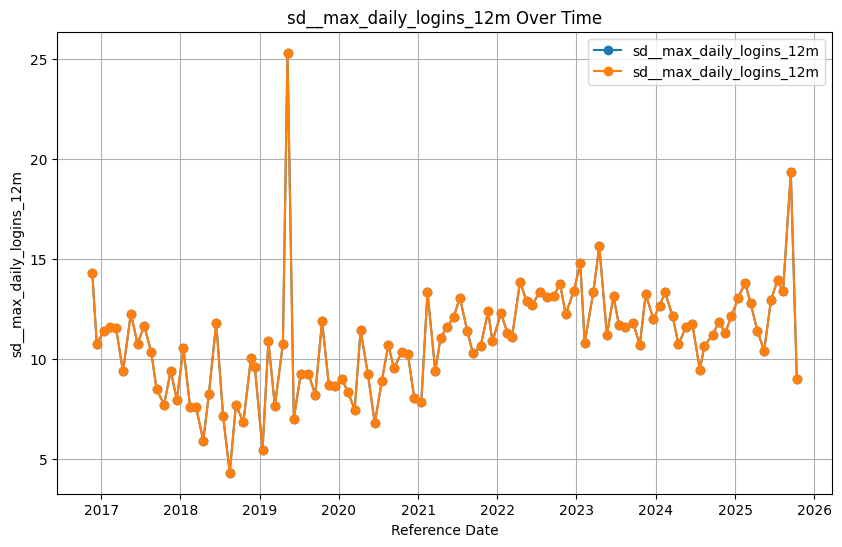

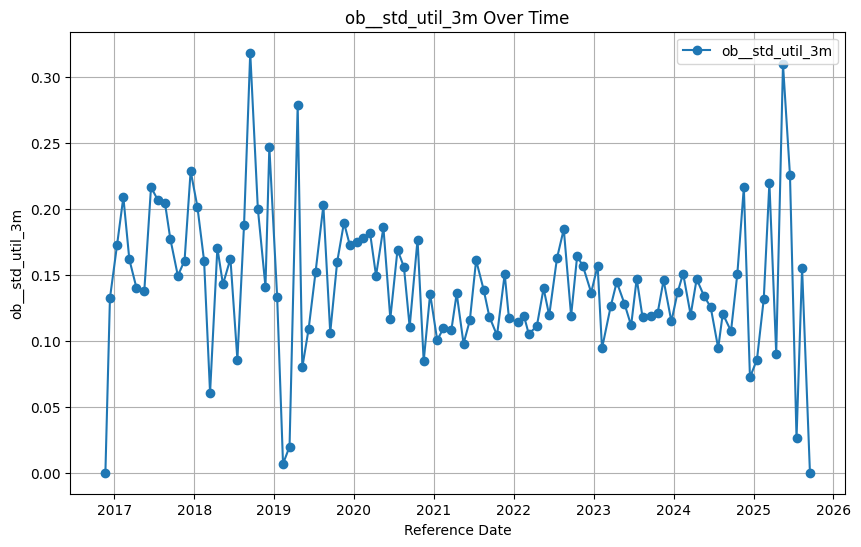

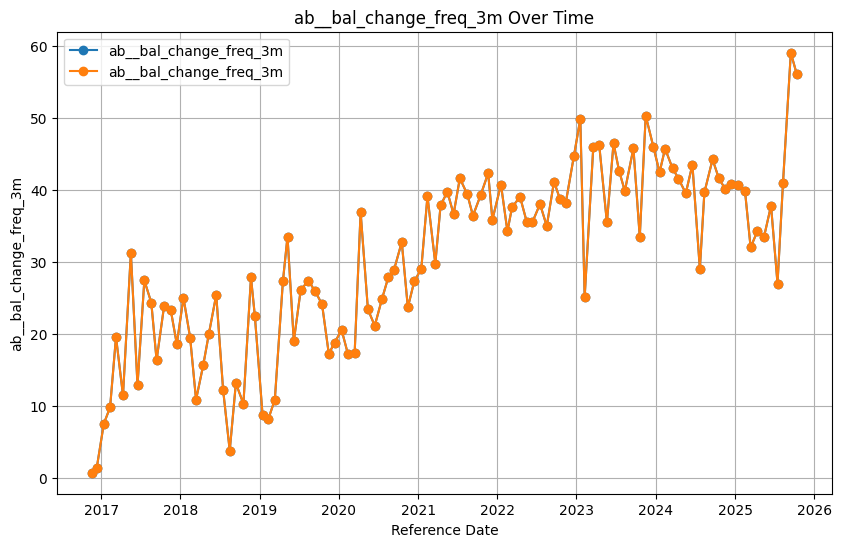

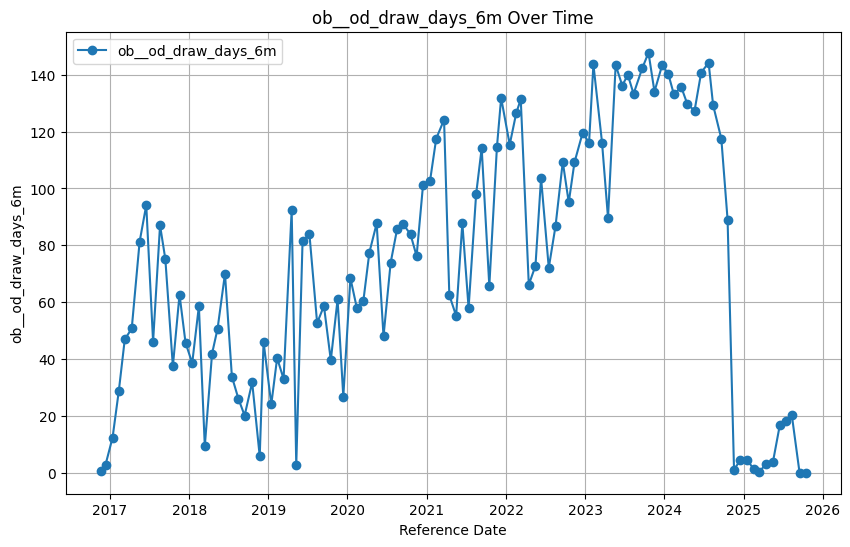

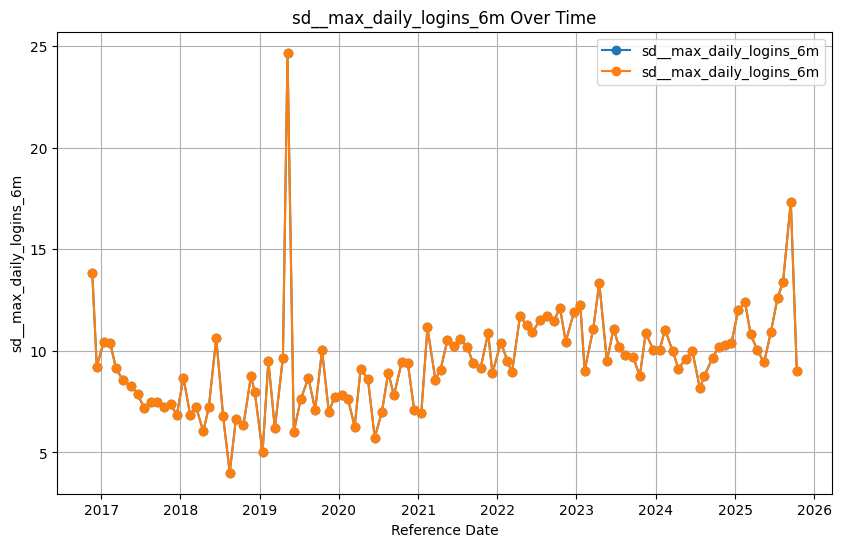

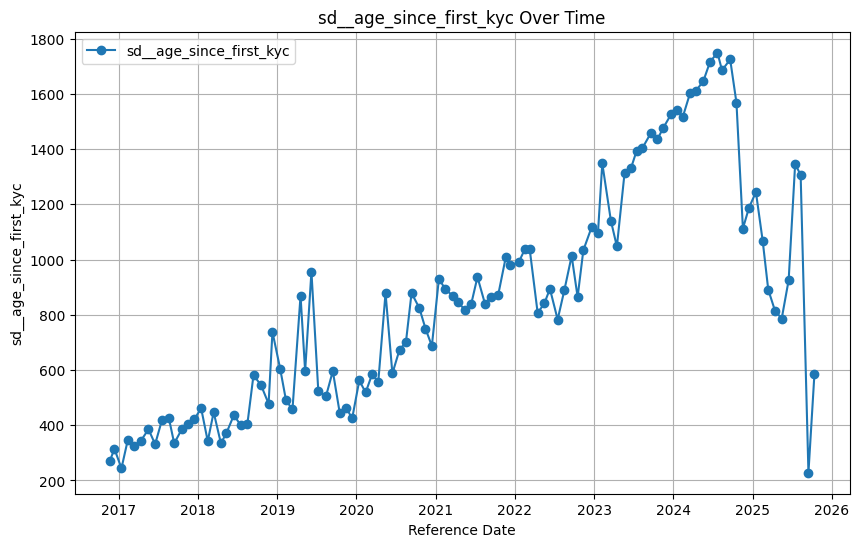

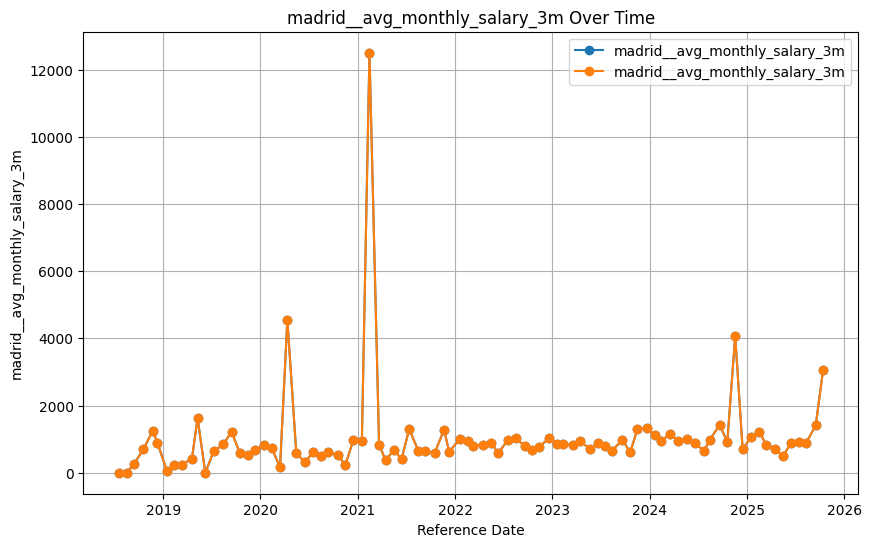

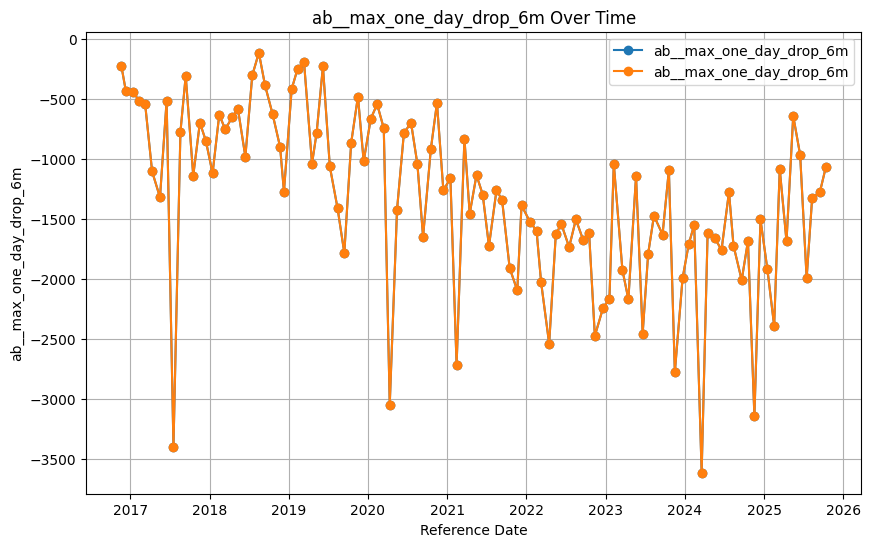

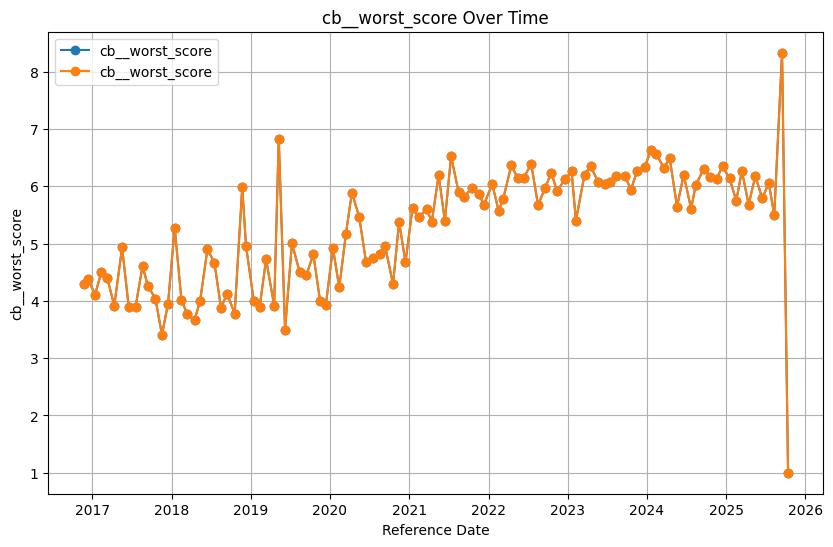

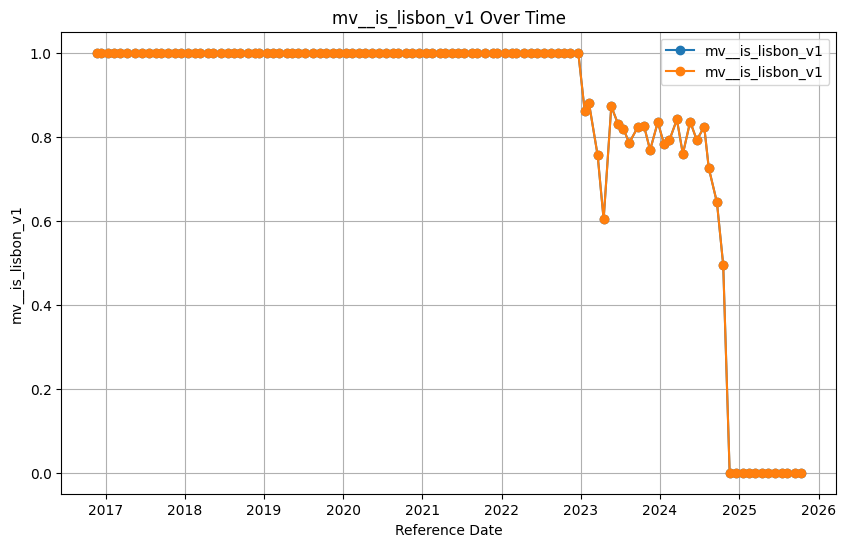

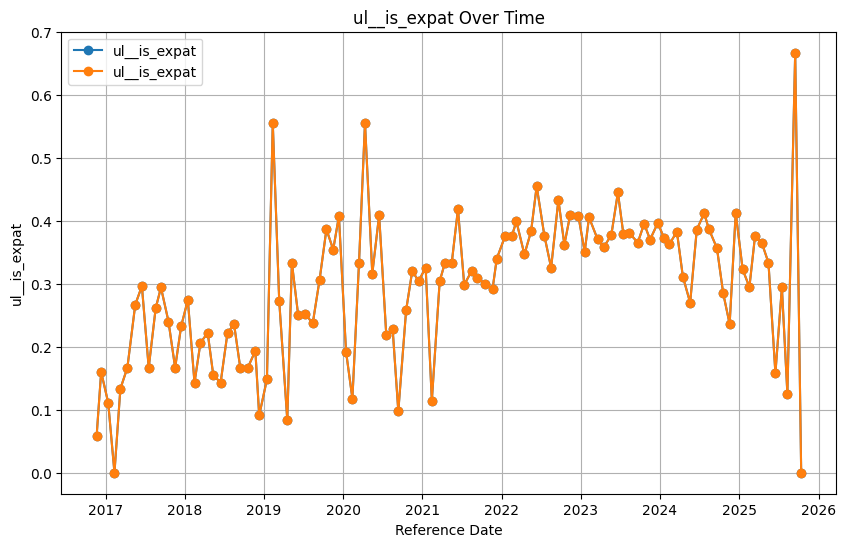

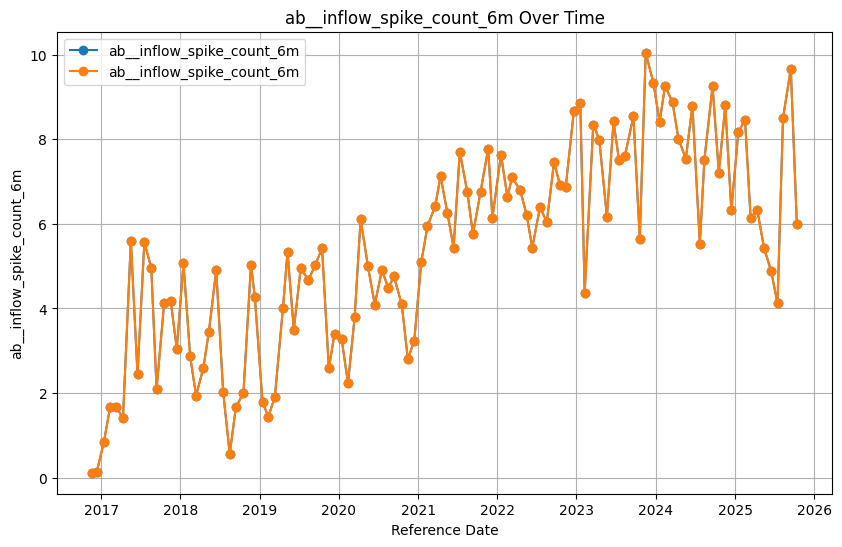

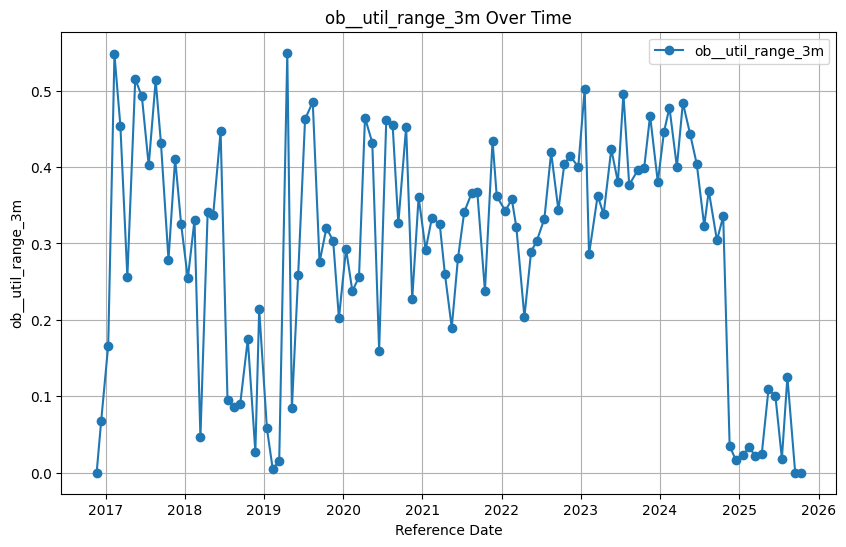

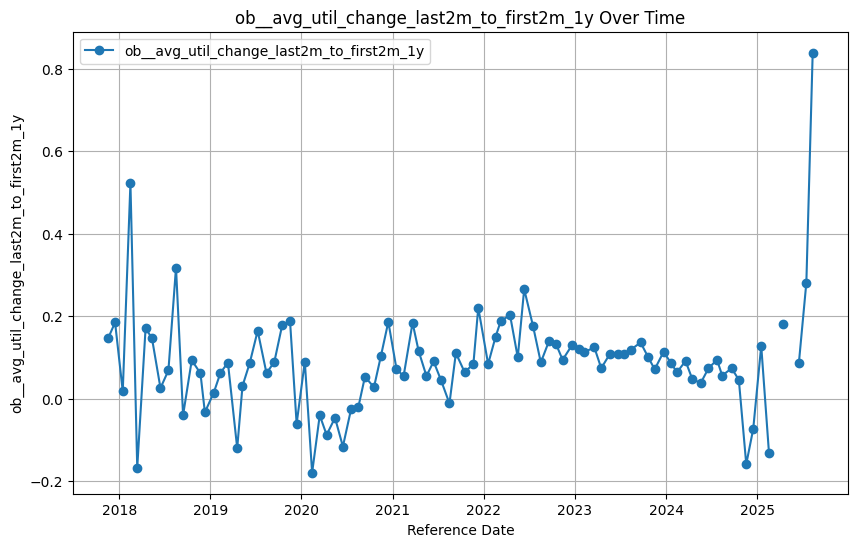

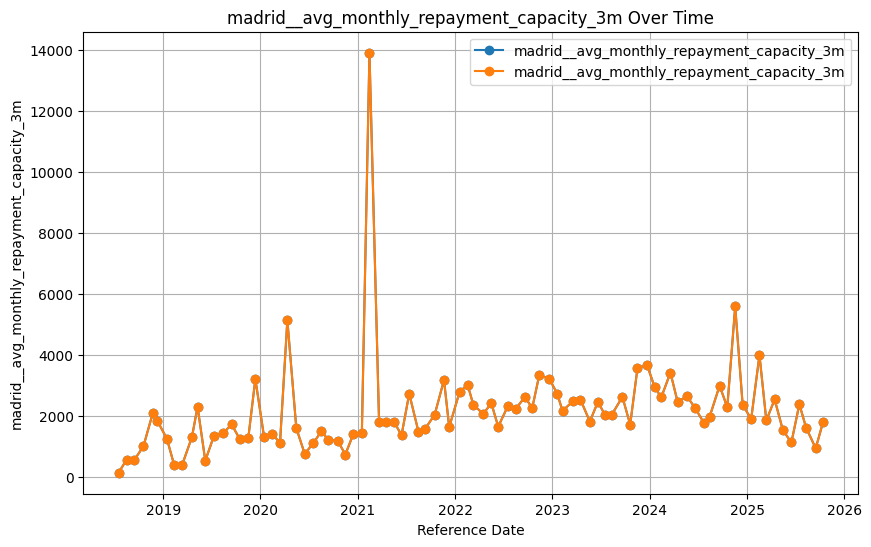

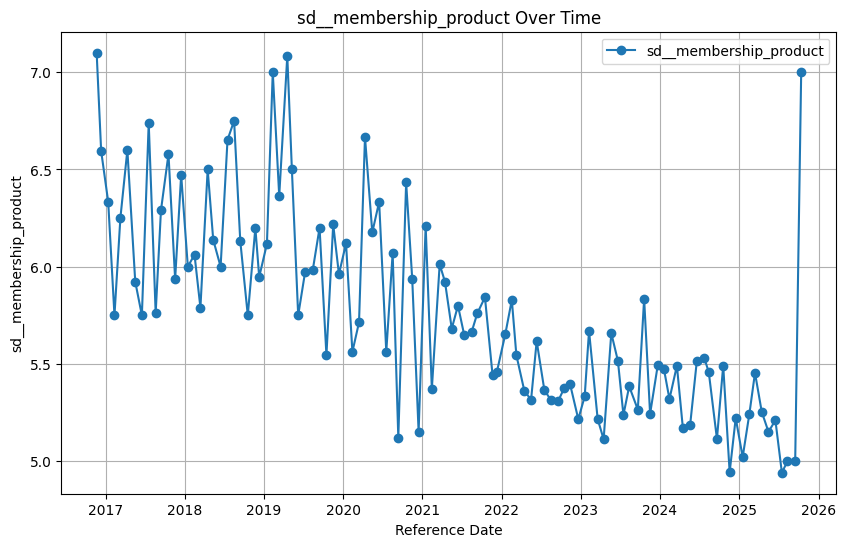

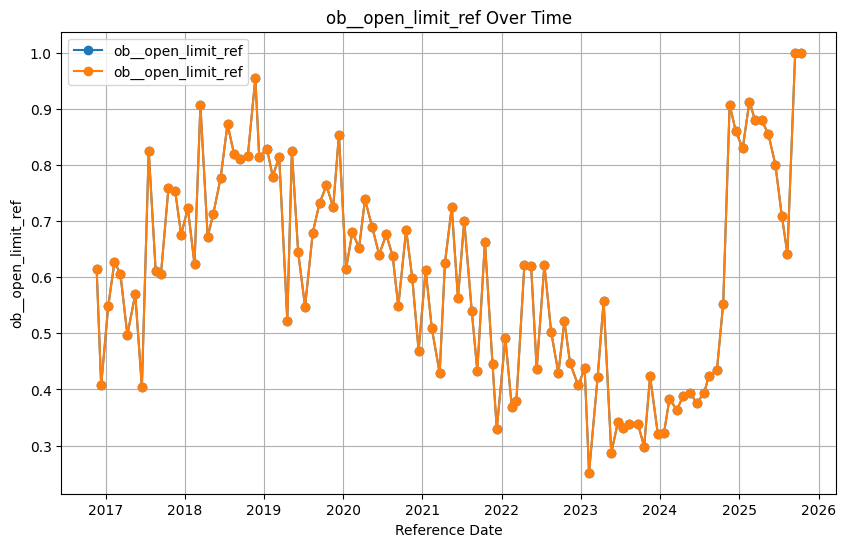

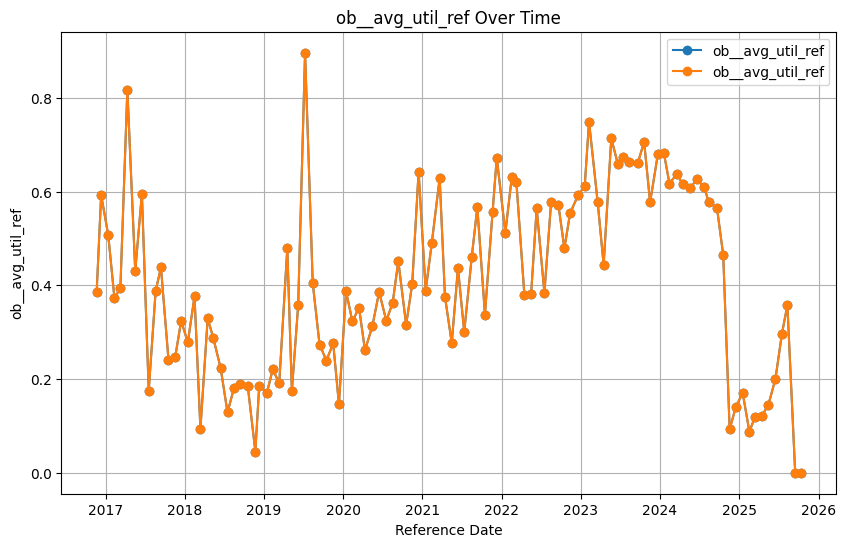

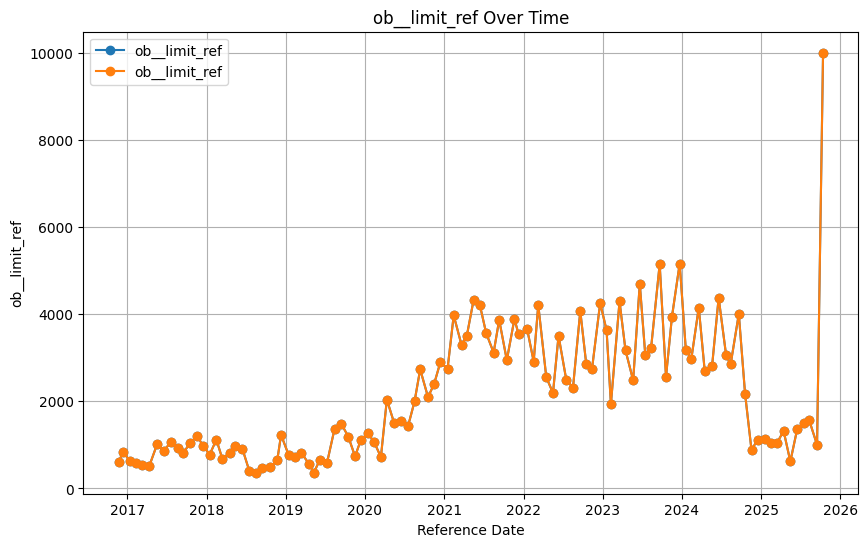

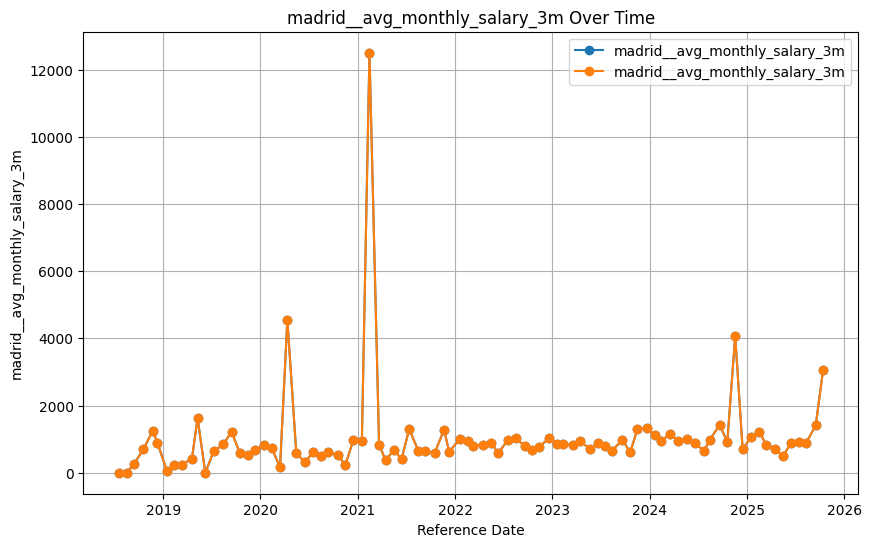

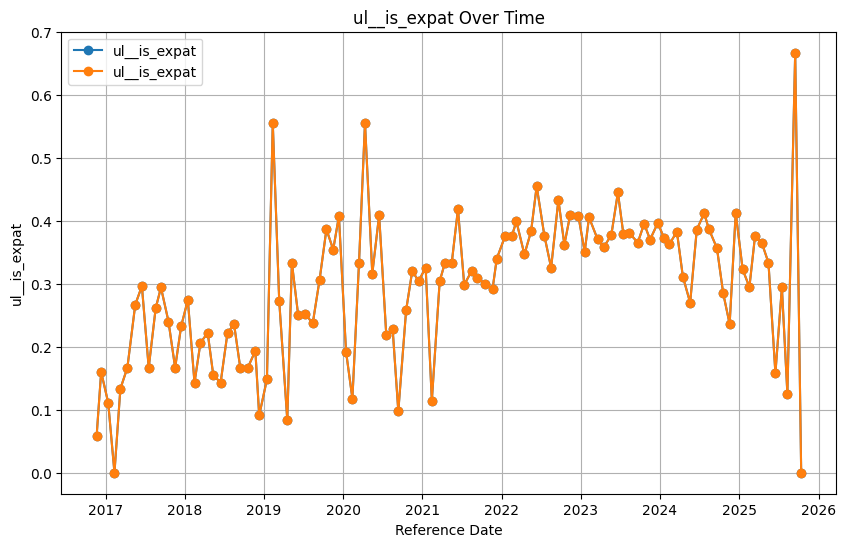

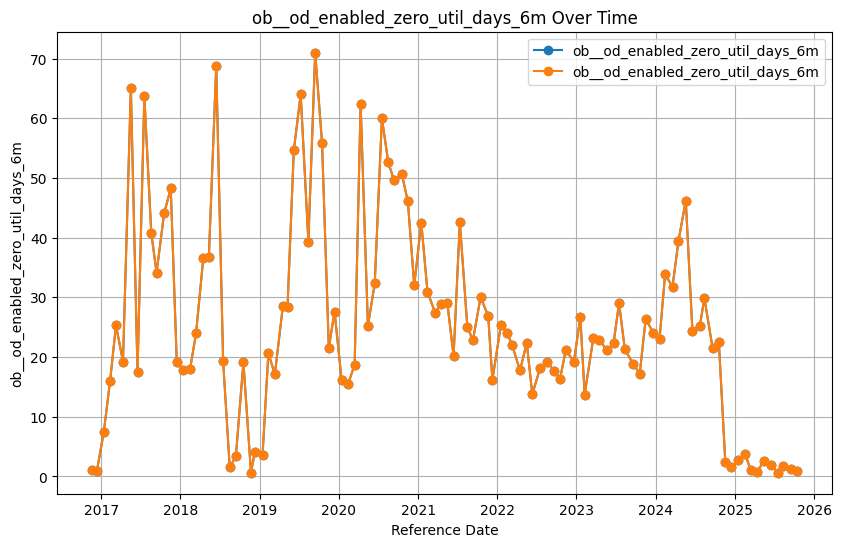

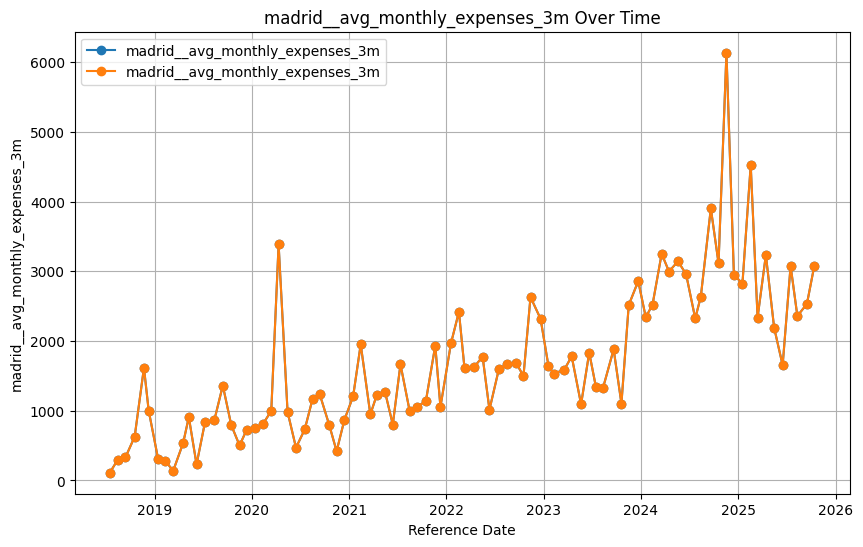

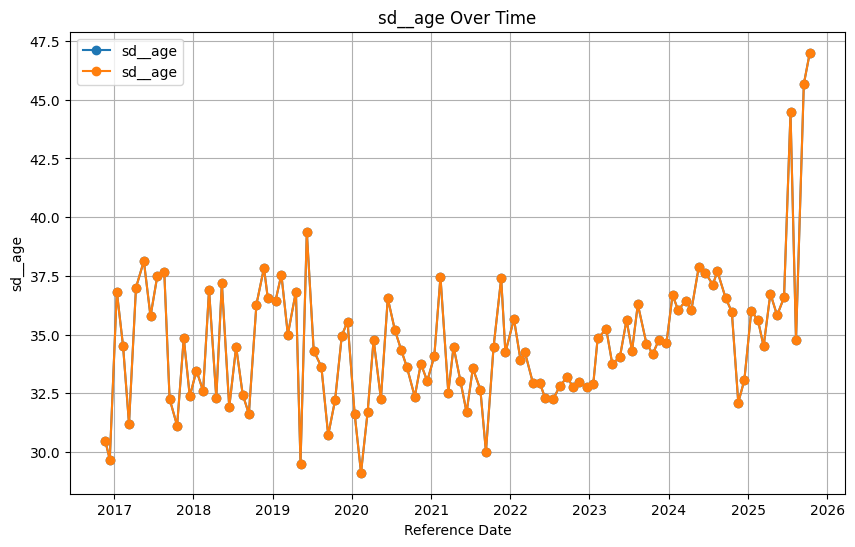

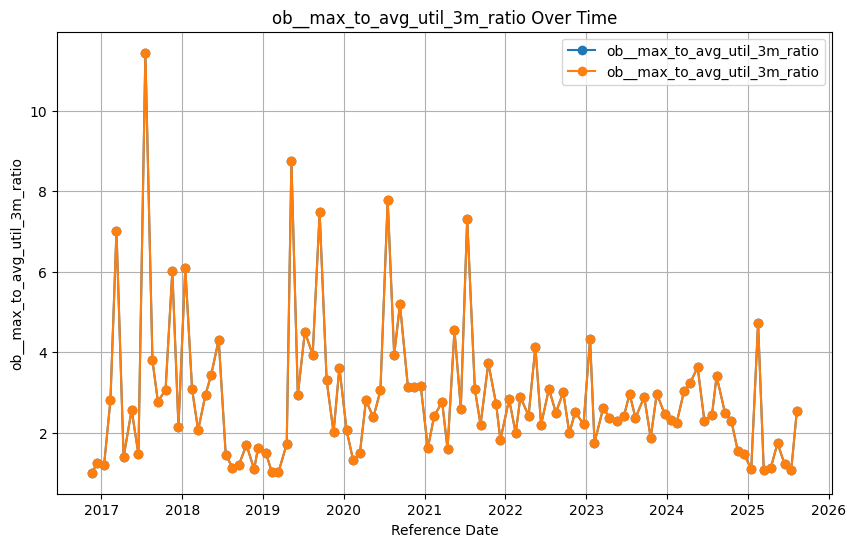

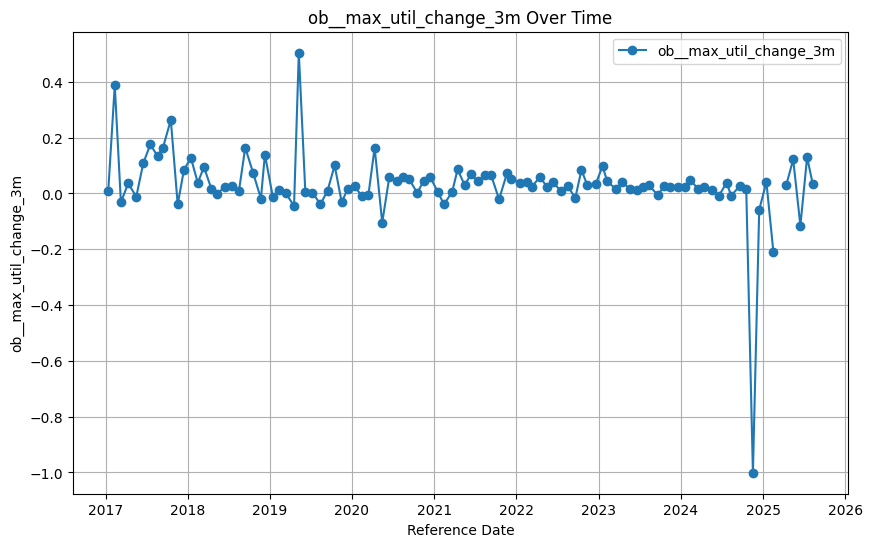

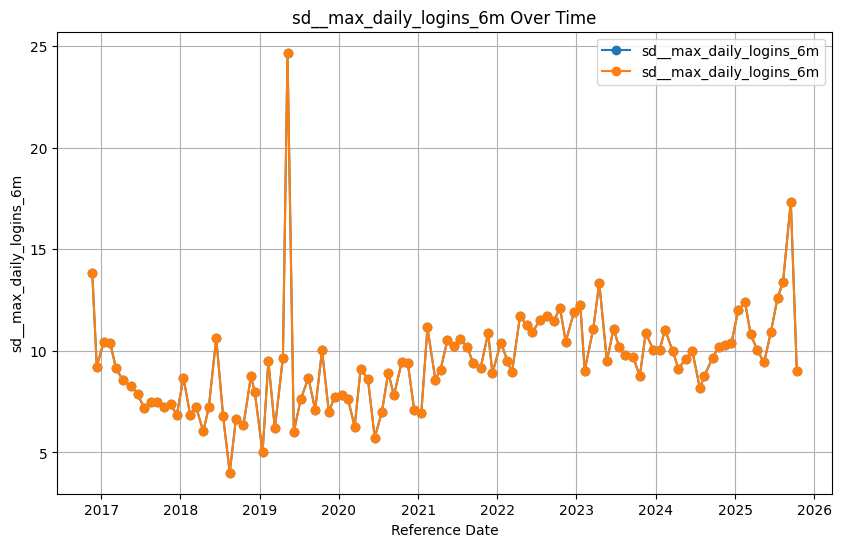

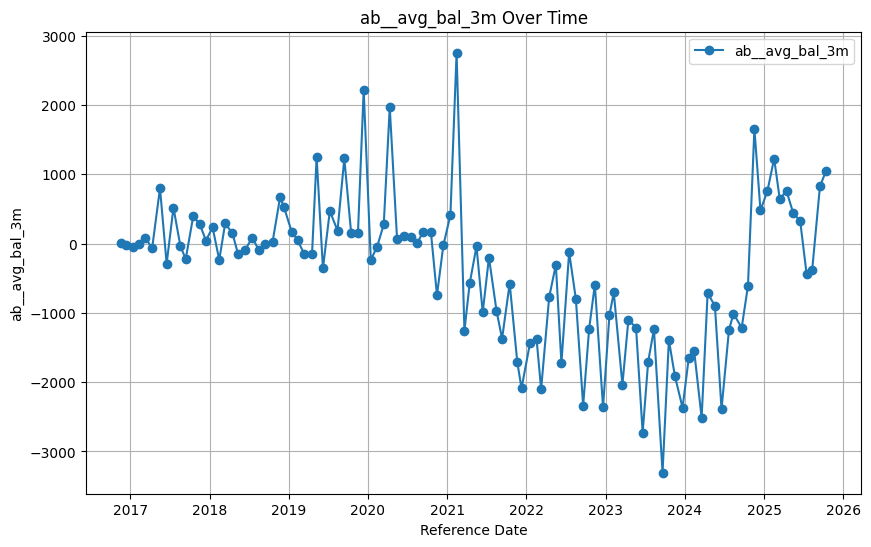

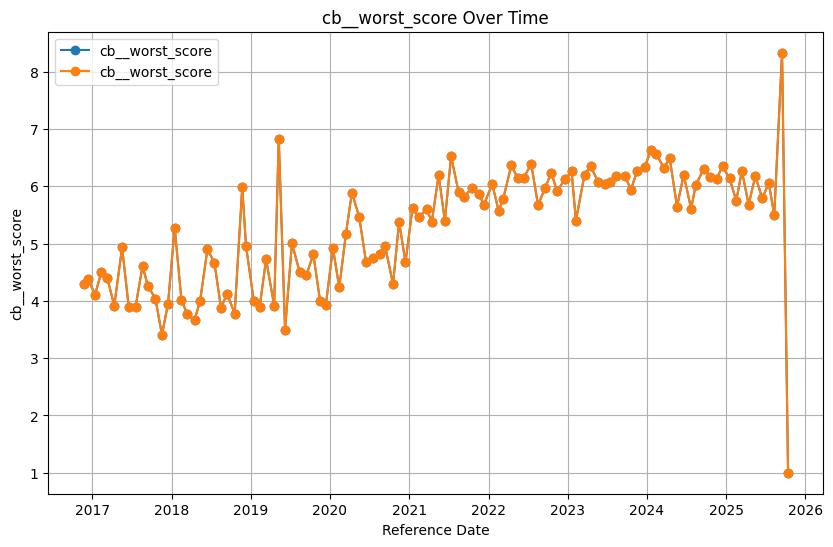

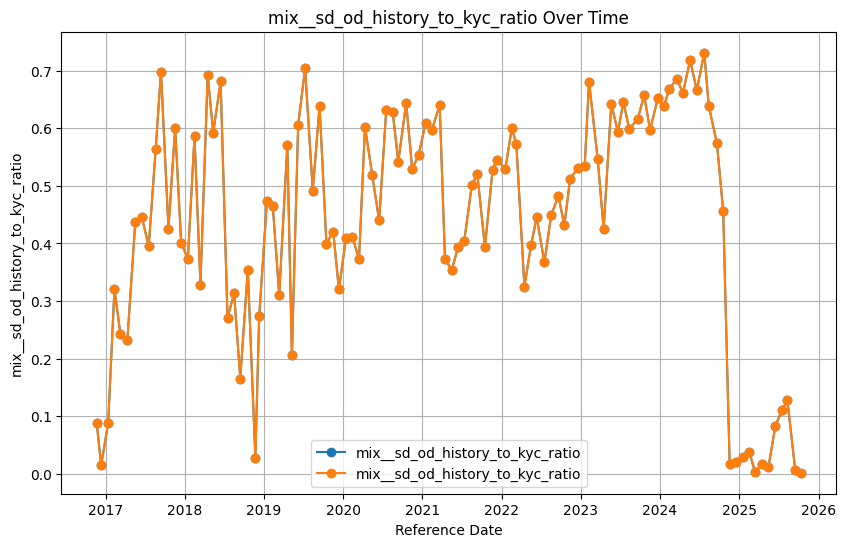

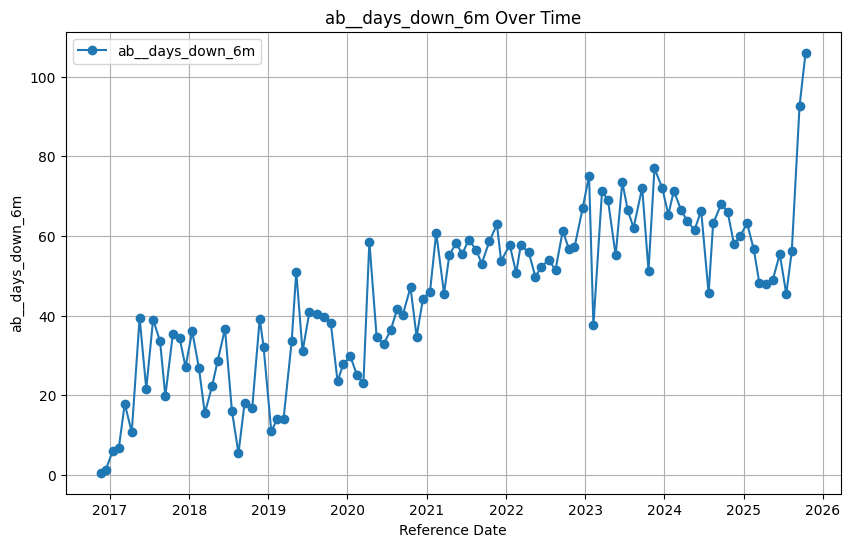

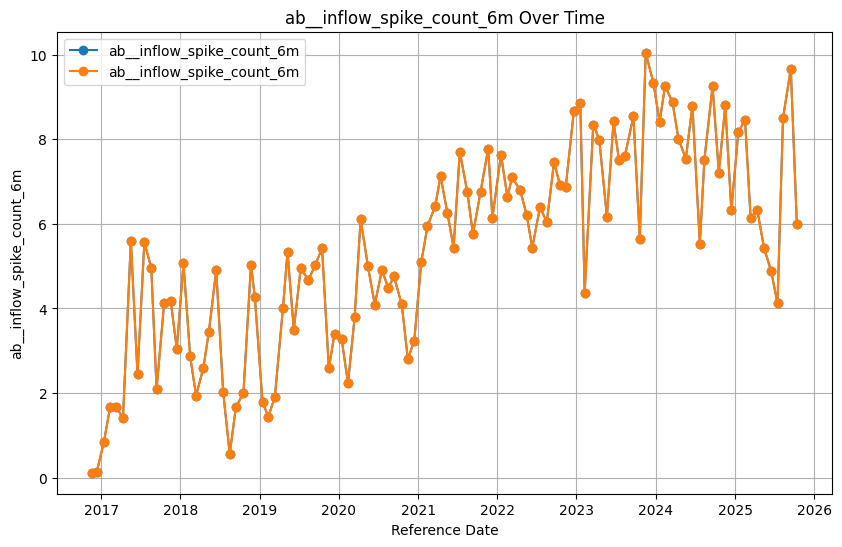

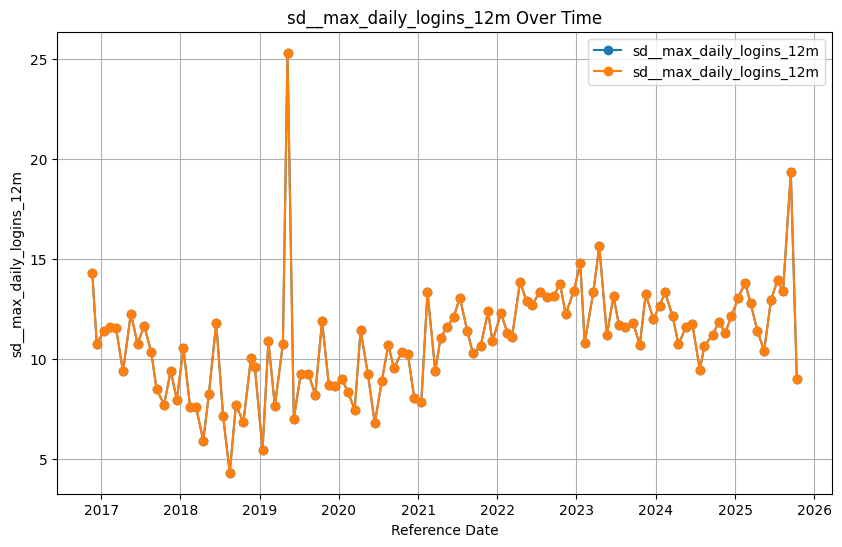

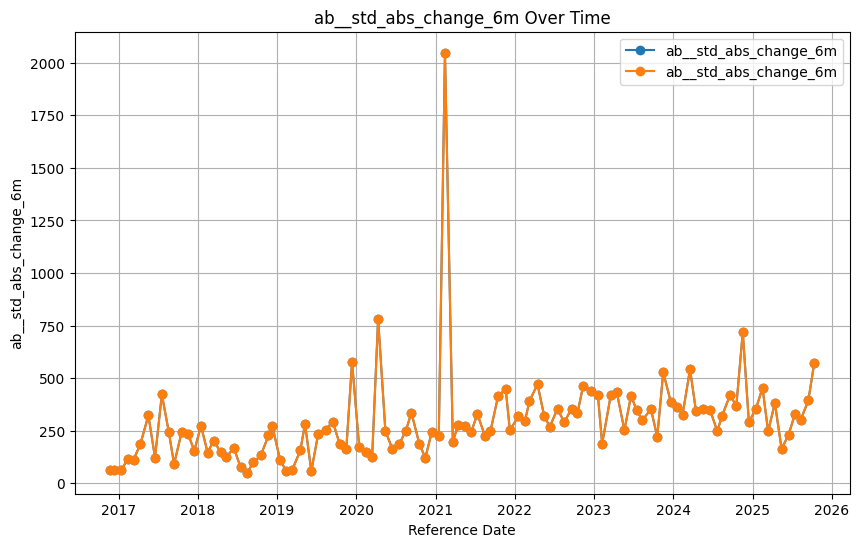

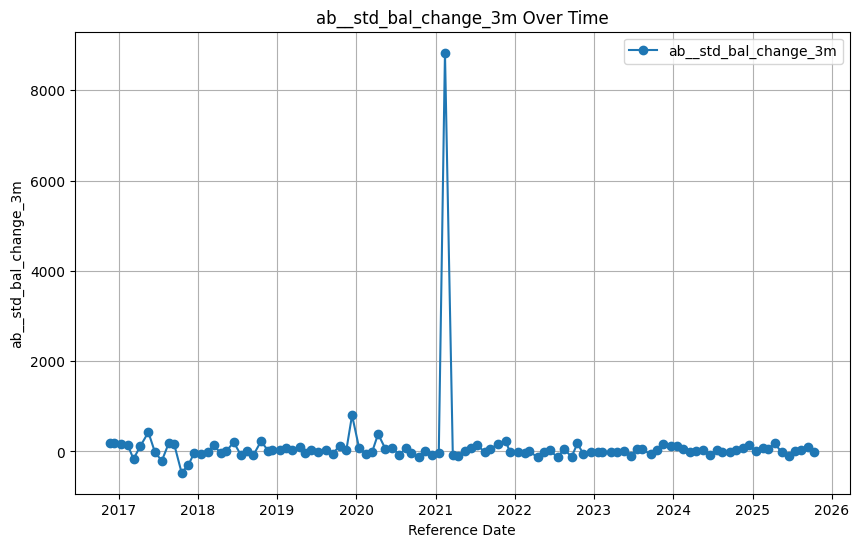

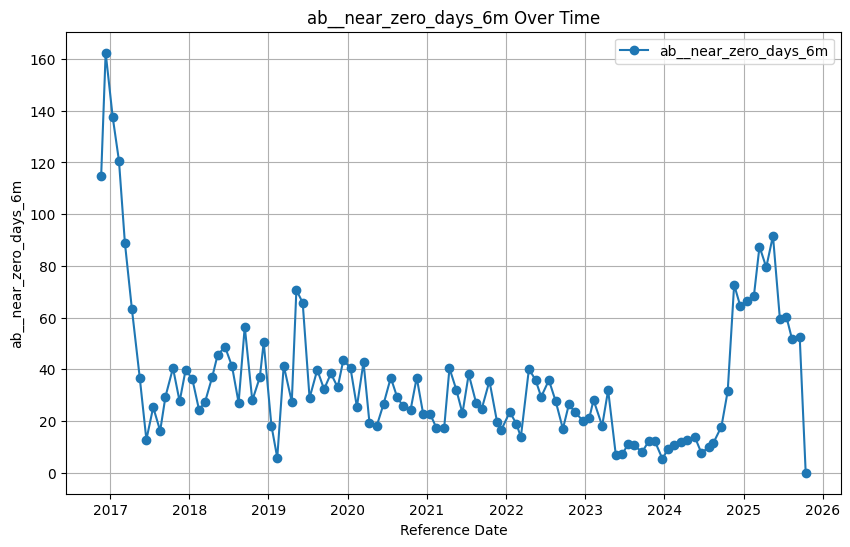

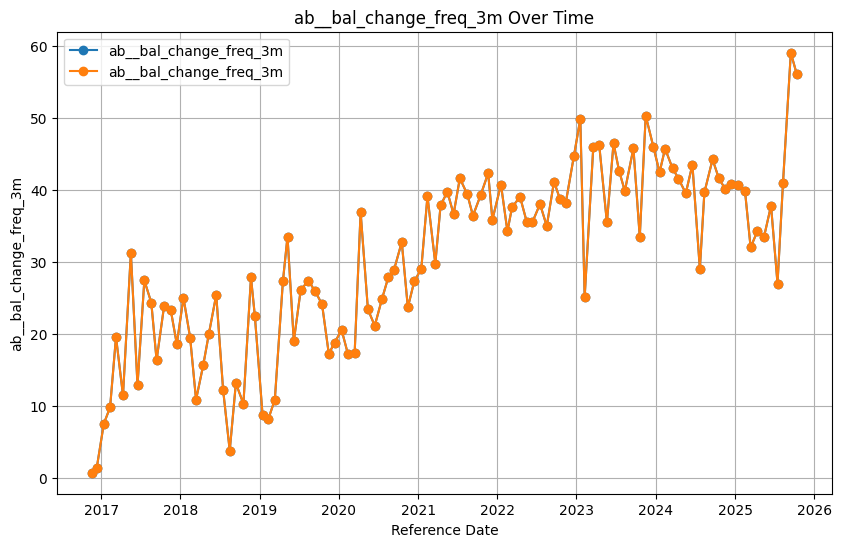

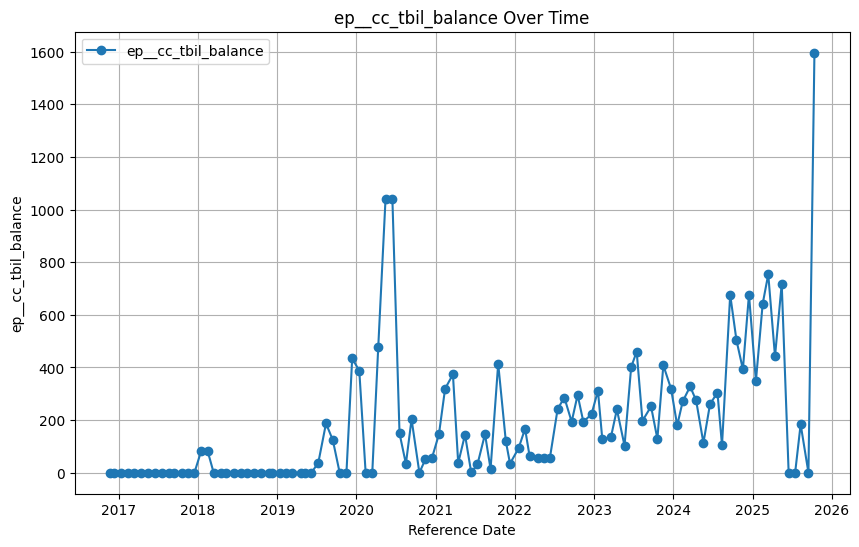

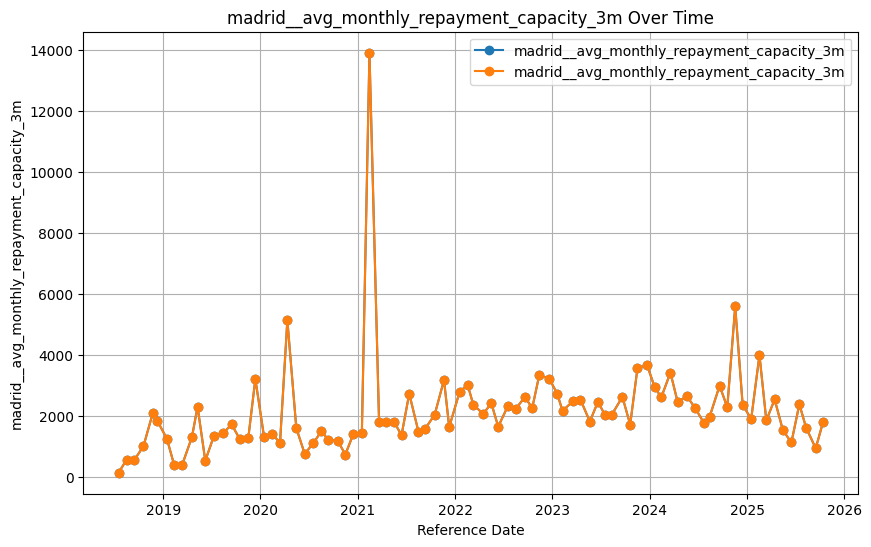

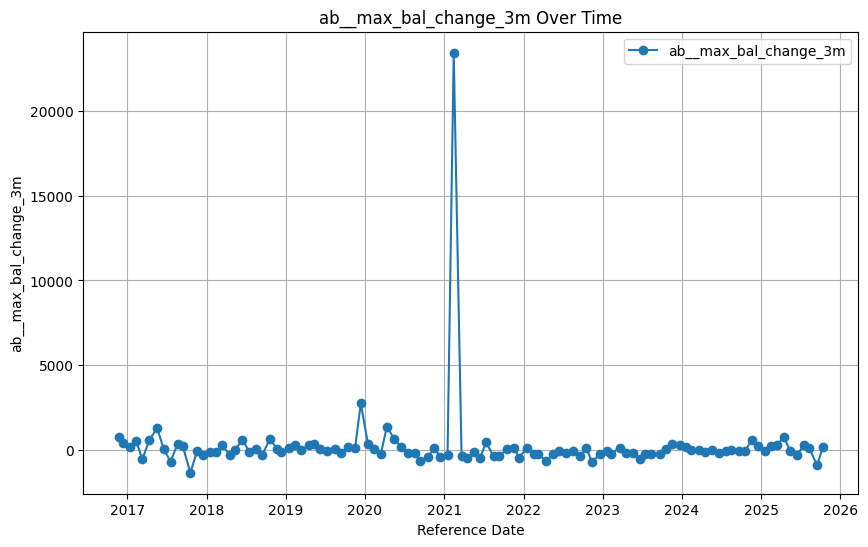

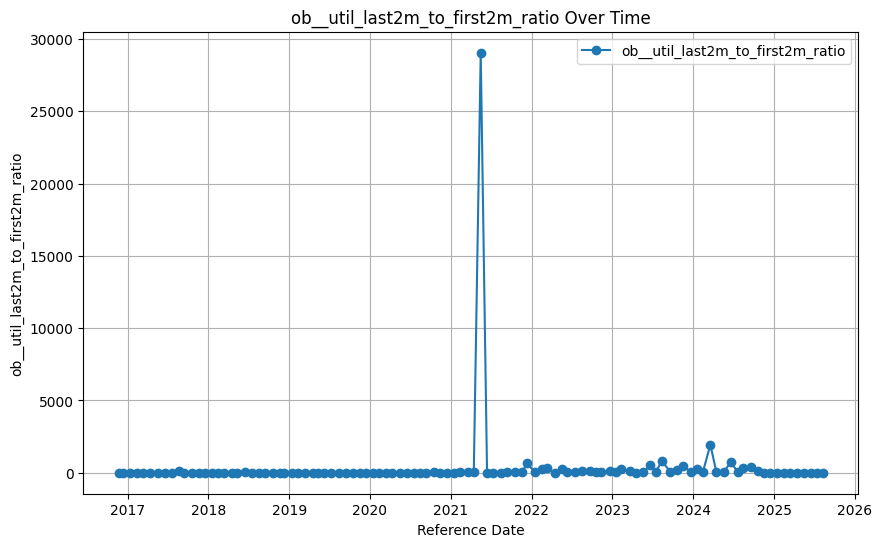

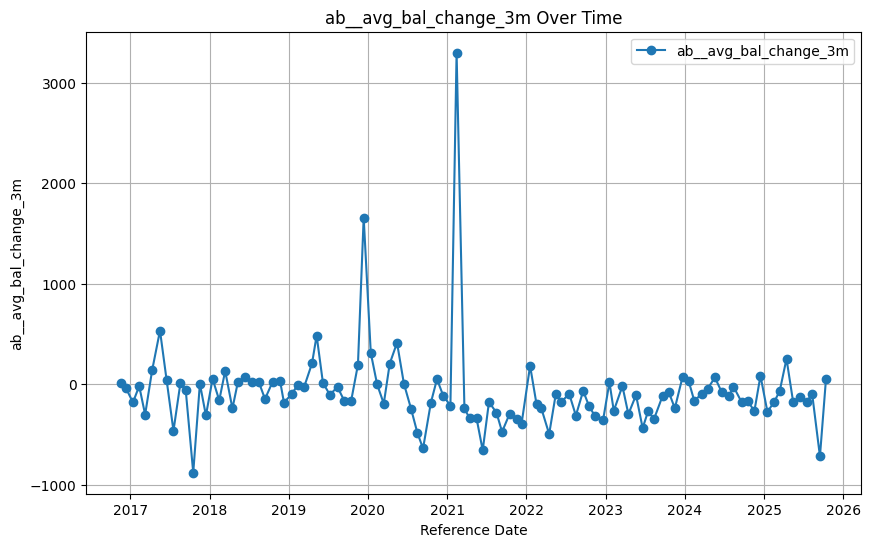

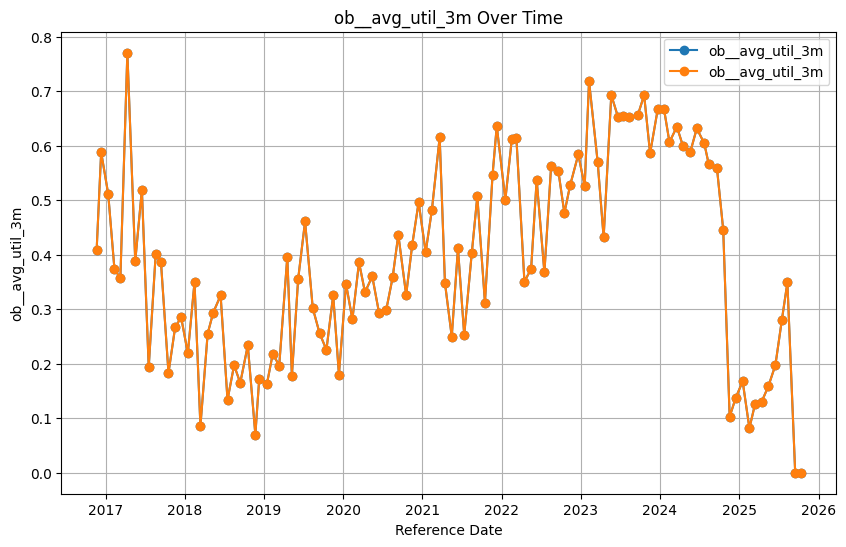

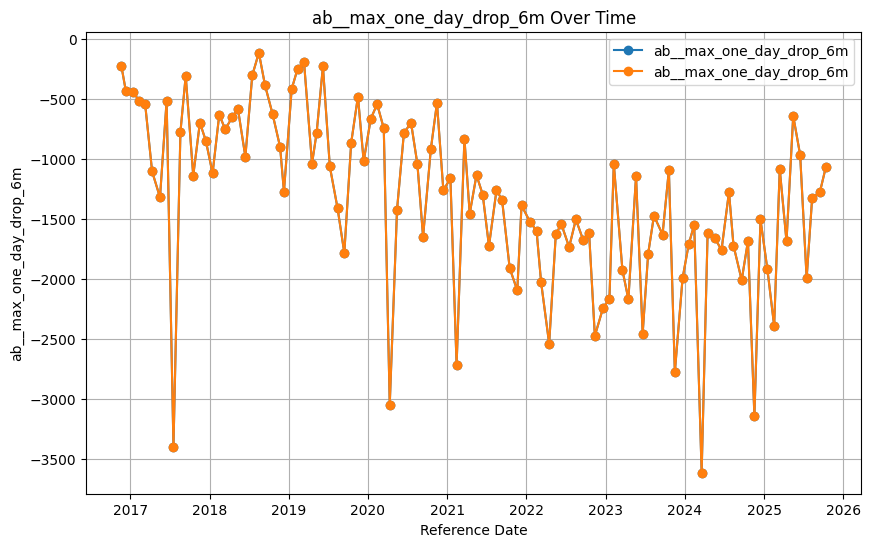

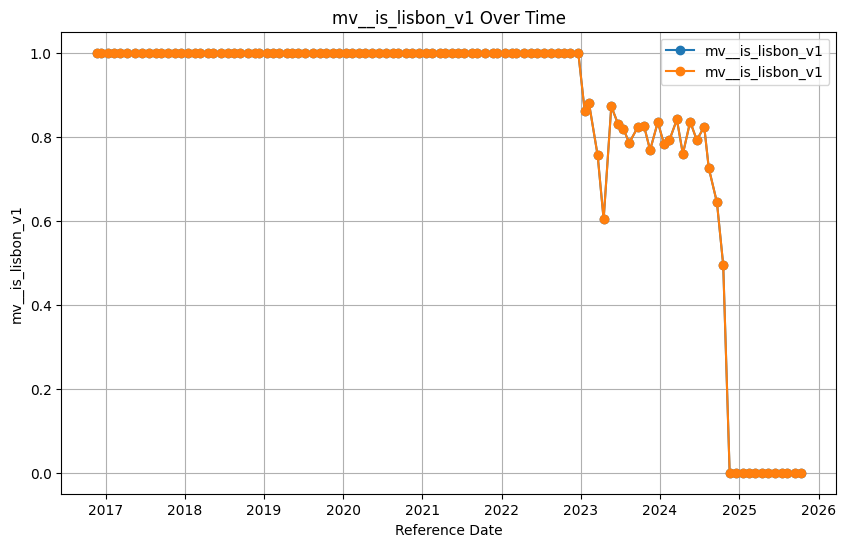

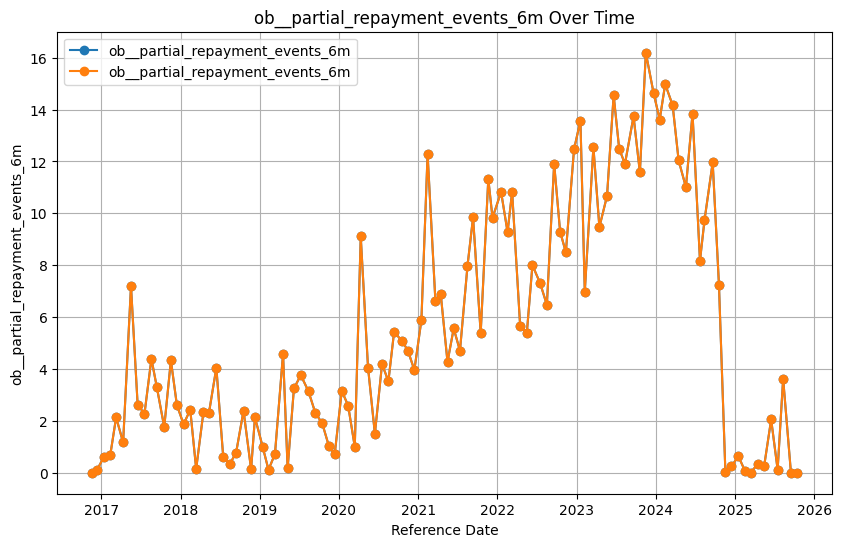

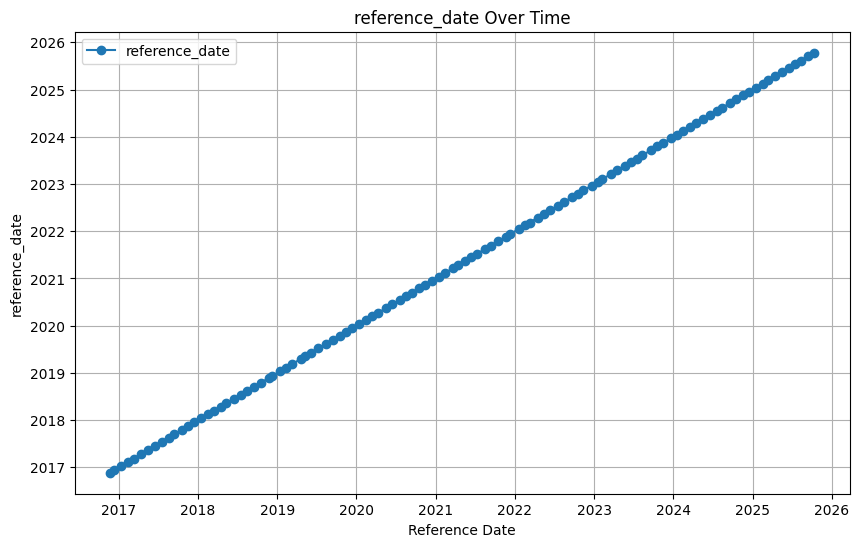

In [70]:
features['reference_date'] = pd.to_datetime(features['reference_date'])

features['eom'] = features['reference_date'] + pd.offsets.MonthEnd(0)

df_eom_avg = features.groupby('eom').mean().reset_index()

features_reg_list = [feature for feature in features_reg.columns if feature != "reference_date"]
features_clf_list = [feature for feature in features_clf.columns if feature != "reference_date"]

all_features = df_eom_avg[features_reg_list + features_clf_list + ['reference_date']]

for feature in all_features:
    plt.figure(figsize=(10, 6))
    
    plt.plot(all_features['reference_date'], all_features[feature], marker='o', linestyle='-', label=feature)
    
    # Add labels, title, and legend
    plt.xlabel('Reference Date')
    plt.ylabel(feature)
    plt.title(f'{feature} Over Time')
    plt.legend()
    plt.grid(True)
    
    # Show the plot
    plt.show()